<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/dentistry/lecture_10/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_%E2%84%9610_%D0%90%D0%B3%D0%B5%D0%BD%D1%82%D1%8B_%D0%B8_%D0%BC%D1%83%D0%BB%D1%8C%D1%82%D0%B8%D0%B0%D0%B3%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D1%81%D0%B8%D1%81%D1%82%D0%B5%D0%BC%D1%8B_%D0%B2_%D1%81%D1%82%D0%BE%D0%BC%D0%B0%D1%82%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D0%B8_%D0%B8_%D1%81%D0%BC%D0%B5%D0%B6%D0%BD%D1%8B%D1%85_%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D1%8F%D1%85_%D0%BC%D0%B5%D0%B4%D0%B8%D1%86%D0%B8%D0%BD%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №10: Интеллектуальные агенты и мультиагентные системы в клинической стоматологии


## 1. ВВЕДЕНИЕ

### 1.1. От простых чат-ботов к интеллектуальным агентам: эволюция ИИ в медицине

В предыдущих лекциях мы прошли путь от простых моделей до RAG-систем. Мы научились:

- **Лекция 8** – запускать локальные LLM через **Ollama**, обеспечивая приватность данных, критически важную при работе с медицинской информацией.
- **Лекция 9** – создавать RAG-системы для работы с базой знаний, что позволяет модели опираться на актуальные клинические руководства и научные публикации, а не только на заложенные при обучении данные.

Но что, если модель должна не просто отвечать на вопросы, а **вести клинический диалог**, **планировать** диагностические шаги, **запоминать** предыдущие взаимодействия с пациентом и **использовать инструменты** (например, интерпретировать рентгенологические заключения или данные микробиологического посева)? Что, если для сложной клинической задачи нужна **команда узких специалистов**, а не один универсал?

**Интуитивная аналогия из стоматологической клиники:**

> Представьте современный стоматологический центр. В нём работают **разные специалисты**:
> - **Стоматолог-терапевт** – проводит первичный осмотр, собирает жалобы и анамнез, оценивает состояние полости рта.
> - **Рентгенолог** – анализирует прицельные снимки, ортопантомограммы (ОПТГ) или КЛКТ, описывает патологические изменения в периапикальных тканях, костной структуре, ВНЧС.
> - **Микробиолог** – интерпретирует результаты бактериологического посева, определяет чувствительность патогенной флоры к антибиотикам.
> - **Неонатолог (или педиатр)** – консультирует по вопросам стоматологического здоровья беременных и новорожденных, оценивает риски для плода при лечении матери.
>
> Все они **общаются** друг с другом, **передают** информацию, **обмениваются** наблюдениями в рамках междисциплинарного консилиума. Вместе они создают систему, которая работает лучше, чем каждый по отдельности. При этом у каждого есть **память** – они помнят предыдущие визиты пациента, результаты анализов и динамику лечения.

**Что мы узнаем сегодня:**

- Что такое **агент** в контексте LLM: планирование, память, вызов инструментов.
- Как создать **агента-интервьюера** для сбора стоматологического анамнеза с использованием **LangChain**.
- Что такое **мультиагентные системы** и как агенты кооперируются с помощью **LangGraph** для постановки комплексного диагноза.
- Какие **тренды 2026 года** формируют будущее персонализированных ассистентов в стоматологии и смежных областях медицины.

**Ключевая мысль:** агенты и мультиагентные системы – это следующий уровень ИИ-инструментов для клинической практики. Они позволяют **делегировать** разные задачи разным «специалистам» и **координировать** их работу, создавая системы, которые приближаются к коллегиальному клиническому мышлению.

**Связь с предыдущими лекциями:**

- **Лекция 9** – RAG дал моделям доступ к знаниям. Сегодня мы даём им **способность действовать и принимать решения** в рамках заданного клинического алгоритма.
- **Лекция 7** – мы создавали интерфейсы. Сегодня мы создаём **интеллектуальные системы**, которые сами решают, что делать, имитируя логику врача.

---

### 1.2. Актуальность для стоматологической практики

Современная стоматология сталкивается с растущим объёмом пациентов, необходимостью междисциплинарного подхода и ограниченностью временных ресурсов врача. Агентные системы могут помочь:

| Задача в стоматологии | Как агенты помогают |
|--------|---------------------|
| **Первичный опрос и сбор анамнеза** | Агент-интервьюер собирает жалобы, аллергологический анамнез, соматический статус до приёма врача |
| **Дифференциальная диагностика** | Мультиагентная система анализирует симптомы, данные осмотра и рентгенографии, предлагает диагностические гипотезы (пульпит vs периодонтит, кариес vs гиперестезия) |
| **Интерпретация рентгенологических данных** | Агент-ассистент рентгенолога анализирует протокол КЛКТ, сопоставляет с клинической картиной |
| **Микробиологический мониторинг** | Агент-микробиолог отслеживает результаты посевов, рекомендует антибактериальную терапию с учетом резистентности |
| **Поддержка принятия решений** | Агент предлагает варианты лечения на основе клинических рекомендаций (например, выбор метода эндодонтического лечения) |
| **Профилактика и диспансеризация** | Долгосрочный агент отслеживает состояние пациента между визитами, напоминает о профосмотрах |
| **Неонатальная стоматология** | Агент-консультант оценивает влияние перинатальных факторов на формирование зубочелюстной системы |

**Исследования 2025–2026 годов показывают впечатляющие результаты:**

| Исследование | Что делает | Результаты |
|--------------|------------|------------|
| **WiseMind** | Мультиагентный фреймворк для психиатрической диагностики (адаптируется для диагностики хронической боли в ЧЛО) | **85.6%** точности top-1 диагностики [1] |
| **MoodAngels** | Диагностика расстройств настроения (принцип может быть применен для оценки дентофобии) | На **12.3%** выше точности, чем GPT-4o [4] |
| **AgentMental** | Интерактивная оценка психического здоровья (адаптация для оценки стоматологического статуса) | Объяснимая и адаптивная диагностика [2] |

**Для ординаторов разных специальностей это означает:**

- **Стоматолог-терапевт:** получит инструмент для автоматизации сбора анамнеза и поддержки диагностических решений.
- **Рентгенолог:** сможет использовать агентов как «второе мнение» при анализе сложных случаев (оценка резорбции, очагов деструкции, состояния гайморовых пазух).
- **Микробиолог:** получит агентов для интерпретации антибиотикограмм в контексте одонтогенной инфекции.
- **Неонатолог:** сможет использовать агентов для связи перинатального анамнеза с рисками развития стоматологической патологии у ребенка.

---

## 2. ЧТО ТАКОЕ АГЕНТ

### 2.1. Определение агента

**Агент** – это LLM, которая **сама принимает решения** о том, какие действия выполнить для достижения цели. В отличие от обычного чат-бота, агент может:

- **Планировать** – разбивать сложную клиническую задачу на шаги (например, этапы диагностического поиска).
- **Использовать инструменты** – вызывать функции, API, базы данных (например, поиск по классификации МКБ-10, расчет индекса КПУ, проверка совместимости препаратов).
- **Запоминать** – сохранять контекст и историю взаимодействий (жалобы, анамнез, результаты осмотра).
- **Адаптироваться** – менять стратегию в зависимости от результатов (например, при подозрении на острый воспалительный процесс переключиться на срочный протокол).

**Интуитивная аналогия:**

> Обычный чат-бот – это как **регистратор в клинике**, который выдает заранее заготовленные ответы по скрипту. Агент – это как **опытный врач-стоматолог**, который:
> - Слушает жалобы пациента и **решает**, какие вопросы задать дальше (иррадиация боли? реакция на температурные раздражители?).
> - При необходимости **заглядывает** в карту пациента или на рентгеновский снимок (инструмент).
> - **Помнит**, что пациент рассказал о аллергии на пенициллин 10 минут назад.
> - **Меняет подход**, если видит, что пациент испытывает страх или боль.
> - **Планирует** структуру осмотра и дополнительные методы исследования.

**Ключевые компоненты агента (по аналогии с когнитивной психологией и клиническим мышлением):**

| Компонент | Что делает | Аналогия в стоматологии |
|-----------|------------|----------------------|
| **LLM (ядро)** | Принимает решения, генерирует ответы | Клиническое мышление врача |
| **Память (Memory)** | Хранит историю диалога, факты о пациенте | Медицинская карта, история болезни |
| **Инструменты (Tools)** | Функции, которые может вызывать агент | Инструменты врача: рентген, ЭОД, пародонтальный зонд, анализы |
| **Планировщик (Planner)** | Разбивает задачу на шаги | Составление плана лечения |
| **Рефлексия (Reflection)** | Оценивает свои действия и корректирует | Клинический разбор, супервизия, контроль качества лечения |

### 2.2. Архитектура агента


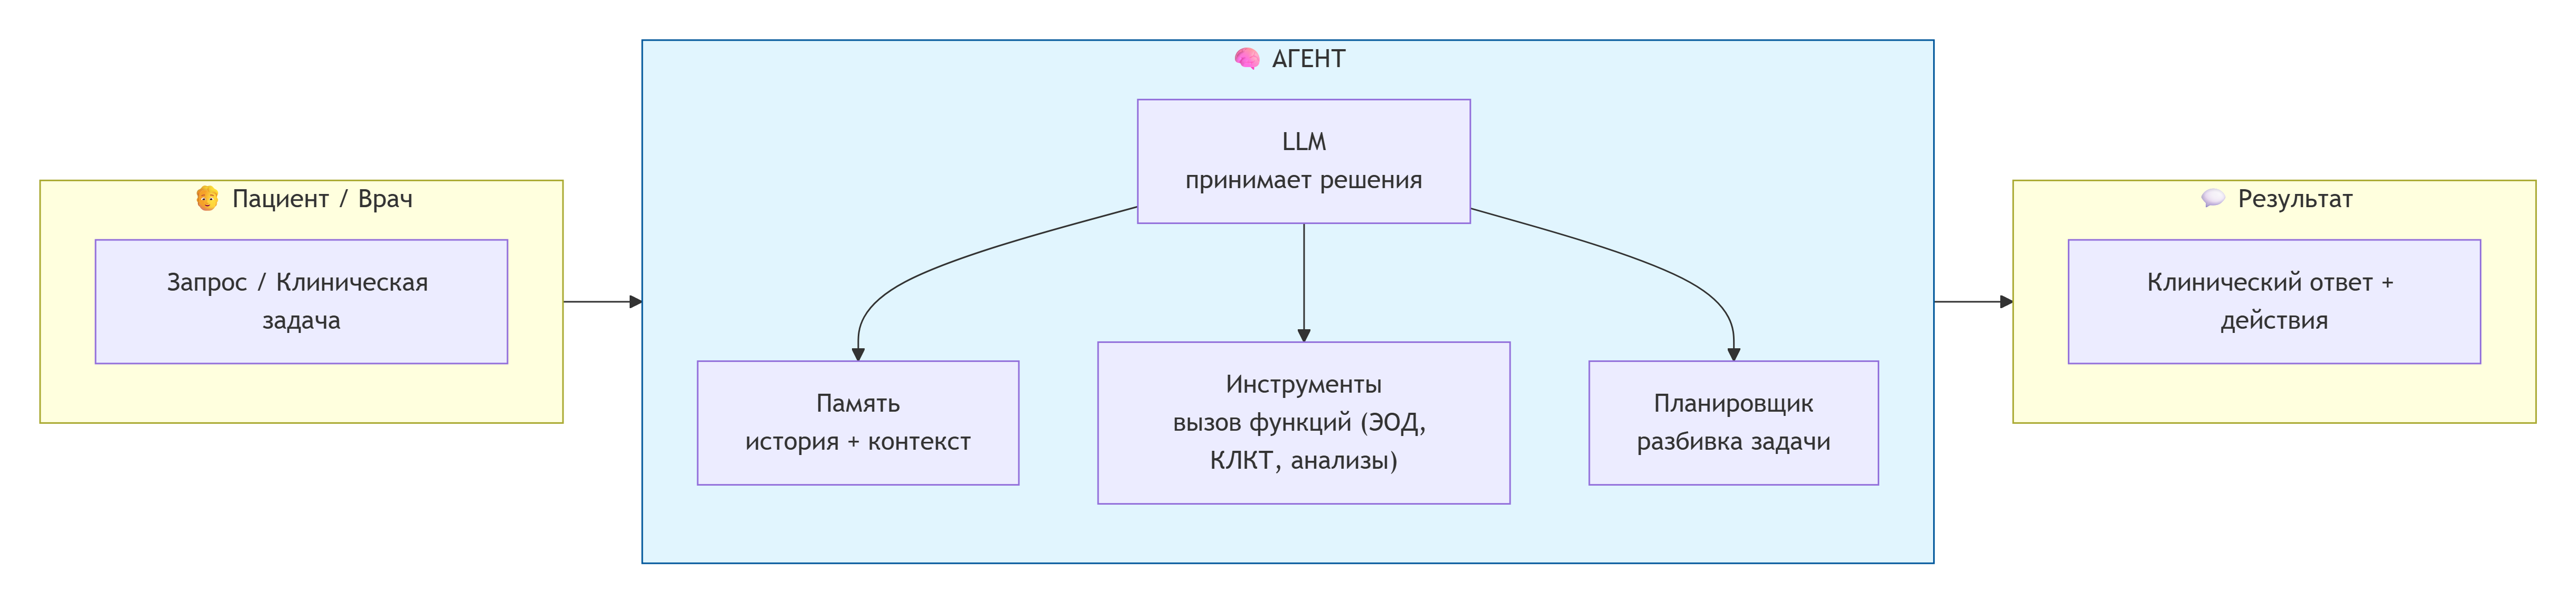



### 2.3. Память агента: краткосрочная и долгосрочная

В когнитивной психологии выделяют рабочую (краткосрочную) и долгосрочную память. В агентных системах используется аналогичный принцип. Для стоматологии это критически важно, так как лечение часто многоэтапное и разнесено во времени.

| Тип памяти | Что хранит | Пример в стоматологическом агенте |
|------------|------------|--------------------------------|
| **Краткосрочная (рабочая)** | Текущий диалог, последние сообщения | Что пациент сказал в этом визите: жалобы на боль при накусывании, появилась вчера |
| **Долгосрочная** | Информация о пациенте, история визитов | Факты из предыдущих визитов: ранее лечили 46 зуб по поводу кариеса, аллергия на новокаин, индекс гигиены был плохой |

**Современные подходы к памяти в агентах:**

Исследование 2026 года представляет **EvoMem** – мультиагентный фреймворк с двойным эволюционирующим механизмом памяти, вдохновлённый моделью рабочей памяти. В стоматологии аналогом может быть агент, который «помнит» динамику заживления после операции или изменение глубины пародонтальных карманов на фоне лечения.

**Интуитивная аналогия:**

> Представьте, что врач-стоматолог ведёт пациента с хроническим апикальным периодонтитом. В **рабочей памяти** врача – жалобы на обострение, данные зондирования, перкуторная реакция. В **долгосрочной памяти** – вся история: когда был поставлен диагноз, какое проводилось эндодонтическое лечение, результаты предыдущих рентгенограмм. Хороший врач умеет связывать текущее с прошлым. Агент с памятью делает то же самое.

### 2.4. Инструменты агента

Агент может вызывать **инструменты** – внешние функции, которые расширяют его возможности. Для стоматологического агента это особенно актуально, так как диагностика часто требует интеграции данных из разных источников.

**Примеры инструментов для стоматологического агента:**

| Инструмент | Что делает | Пример использования |
|------------|------------|---------------------|
| **DSM-5 / МКБ-10 поиск** | Ищет диагностические критерии | Агент проверяет, соответствует ли клиническая картина критериям «Хронический апикальный периодонтит» (K04.5) |
| **Оценка риска** | Вычисляет риск одонтогенной инфекции или риск кровотечения | Агент оценивает риск развития флегмоны на основе симптомов (дисфагия, тризм, повышение температуры) |
| **Опросник (индекс)** | Проводит стандартизированную оценку | Агент задаёт вопросы для расчета индекса гигиены (OHI-S), индекса CPITN, шкалы дентофобии |
| **Поиск по рентгенологическим паттернам** | Анализирует описание снимка | Агент находит сходства с паттернами резорбции, остеопороза, периапикальной деструкции |
| **Проверка лекарственных взаимодействий** | Проверяет совместимость препаратов | Агент предупреждает о несовместимости антибиотика с антикоагулянтами, принимаемыми пациентом |
| **Расчет дозировки** | Рассчитывает дозу анестетика или антибиотика | Агент рассчитывает максимальную дозу лидокаина с учетом веса пациента |



# 3. LANGCHAIN И LANGGRAPH ДЛЯ АГЕНТНЫХ СИСТЕМ

---

## 3.1. LangChain как фундамент для агентов

**LangChain** – это фреймворк для разработки приложений на основе LLM [14]. Он предоставляет инструменты для создания агентов, цепочек, памяти и интеграций.

**Интуитивная аналогия:**

> LangChain – это как **стоматологическая установка** или набор модульных инструментов. У вас есть готовые детали: модели (LLM через Ollama), наконечники (инструменты: поиск по МКБ-10, интерпретация анализов), память (карта пациента). Вы собираете из них нужную конфигурацию – бота для первичного опроса, агента для анализа снимков, систему поддержки решений.

**Почему LangChain важен для клиницистов:**

| Причина | Объяснение |
|---------|------------|
| **Быстрая разработка** | Позволяет создавать прототипы ИИ-ассистентов для клиники за часы, а не месяцы |
| **Гибкость** | Можно менять модели и инструменты без переписывания всего кода (например, заменить модель анализа снимков) |
| **Память** | Критически важно для ведения диалога с пациентом, где контекст накапливается |
| **Интеграция с RAG** | Подключает базу знаний (клинические протоколы, руководства) |
| **Агентность** | Модель сама решает, какие инструменты использовать (например, когда нужно запросить данные рентгена, а когда – микробиологии) |

**Основные компоненты LangChain для агентов:**

| Компонент | Что делает | Как используется в стоматологии |
|-----------|------------|------------------------------|
| **LLM** | Базовая модель | Ollama (Qwen2.5, DeepSeek-R1) |
| **Tools** | Инструменты агента | Поиск по МКБ-10, оценка риска, интерпретация рентгена |
| **Memory** | Хранение контекста | История диалога с пациентом, данные о предыдущих визитах |
| **Agent** | Принимает решения | Какой инструмент вызвать (например, при подозрении на периодонтит – запросить оценку риска) |
| **Chain** | Последовательность шагов | Опрос → Анализ симптомов → Рентген → Рекомендация |

**Интуитивная аналогия каждого компонента:**

| Компонент | Аналогия в стоматологической практике |
|-----------|------------------------|
| **LLM** | Клиническое мышление врача |
| **Tools** | Инструменты врача: ЭОД, рентген, пародонтальный зонд, анализы |
| **Memory** | Медицинская карта, история болезни, снимки |
| **Agent** | Врач, который решает, какой метод диагностики применить следующим |
| **Chain** | Алгоритм обследования пациента (стандартный протокол осмотра) |

---

## 3.2. LangGraph для мультиагентных систем

**LangGraph** – это библиотека на основе LangChain для построения **состоятельных, мультиагентных приложений** [15]. Она позволяет создавать **графы**, где каждый узел – это шаг обработки (например, агент-специалист), а рёбра – переходы между шагами.

**Интуитивная аналогия:**

> Если LangChain – это **набор инструментов врача**, то LangGraph – это **маршрутизация пациента в многопрофильной клинике**. Например, пациент приходит с жалобами на боль в области верхней челюсти. LangGraph определяет путь:
> - Сначала к **стоматологу-терапевту** (сбор жалоб, осмотр).
> - Затем, при необходимости, к **рентгенологу** (ОПТГ или КЛКТ).
> - Если есть подозрение на одонтогенную инфекцию – к **микробиологу** (посев).
> - **Супервизор** (зав. отделением) контролирует качество на каждом этапе.
>
> В отличие от простой цепочки (Chain), LangGraph позволяет **возвращаться** на предыдущие шаги (например, если данные рентгена потребовали уточнить анамнез) и **ветвиться** в зависимости от результатов.

**Ключевая особенность:** LangGraph поддерживает **состояние (state)** – информация сохраняется и передаётся между узлами. Это критически важно для клинических диалогов, где контекст накапливается, и для диагностических алгоритмов, где каждый следующий шаг зависит от предыдущих.

**Для врача это означает:**

| Возможность LangGraph | Как это помогает в стоматологии |
|-----------------------|-------------------------------|
| **Ветвление** | Если пациент сообщает о тризме и температуре – система переходит в режим неотложной помощи (подозрение на флегмону) |
| **Циклы** | Если данных рентгена недостаточно – агент возвращается к этапу сбора анамнеза или запрашивает другой тип снимка (прицельный вместо ОПТГ) |
| **Состояние** | Все агенты (терапевт, рентгенолог, микробиолог) имеют доступ к полной клинической картине |
| **Память** | Система помнит, что пациент сказал ранее и какие данные уже получены |

---

## 3.3. Схема: LangChain + LangGraph для стоматологического агента


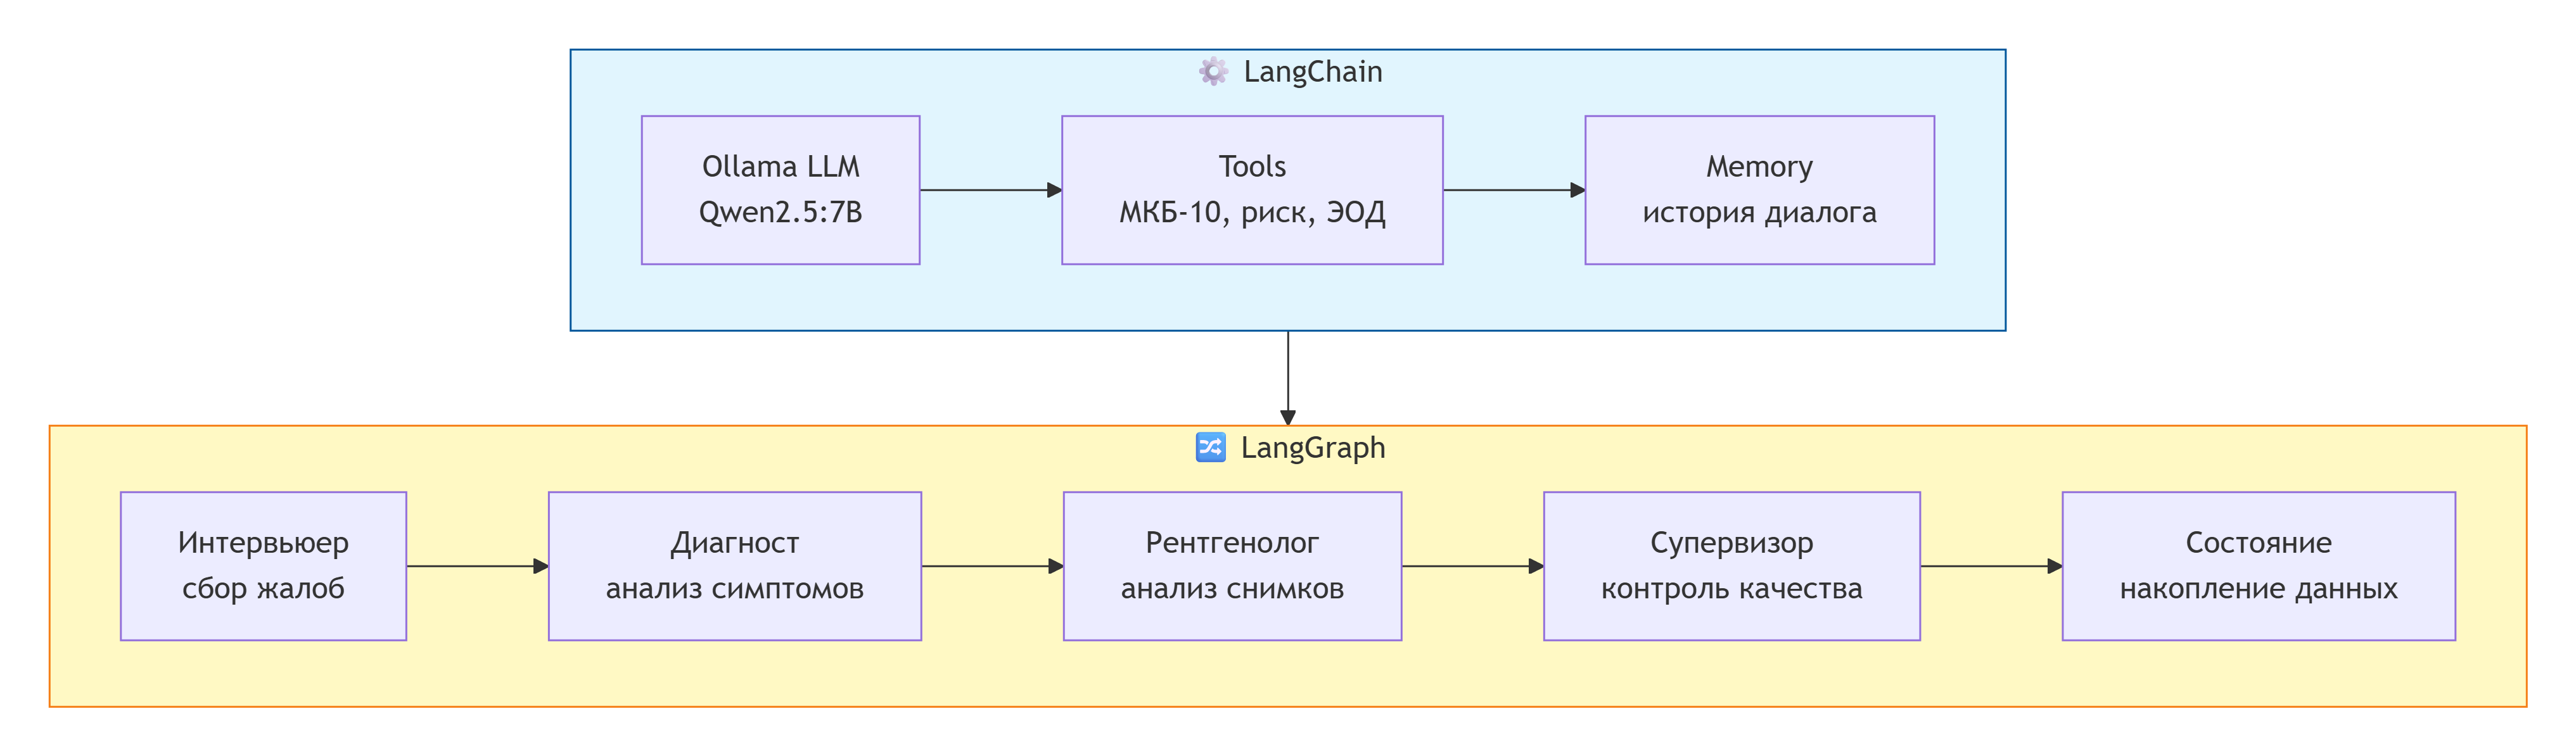


**Пояснение к схеме:**

- **LangChain** предоставляет базовые компоненты: LLM (модель для рассуждений), инструменты (поиск по классификациям, оценка риска, расчет индексов), память (история диалога с пациентом).
- **LangGraph** строит граф, где каждый узел — это специализированный агент (Стоматолог-интервьюер, Диагност, Ассистент рентгенолога, Супервизор).
- **Состояние** передаётся между агентами, обеспечивая непрерывность клинического мышления и накопление данных о пациенте.

---

## 3.4. Код: Single Agent с LangChain (агент-интервьюер стоматологического профиля)

**Что делает этот код:** Создаёт агента-интервьюера для сбора стоматологического анамнеза. Агент использует три инструмента: поиск по МКБ-10, оценку риска одонтогенной инфекции и рекомендацию по тактике лечения. Он запоминает историю диалога и адаптирует вопросы на основе ответов пациента.

**Для ординатора-стоматолога это означает:** Вы можете создать виртуального ассистента, который проводит первичный опрос, выявляет ключевые жалобы, оценивает риски и формирует предварительное заключение для врача.

```python
# ============================================================
# ИТОГОВЫЙ КОД: SINGLE AGENT — АГЕНТ-СТОМАТОЛОГ (ПЕРВИЧНЫЙ ОПРОС)
# ============================================================

import os
import time
import warnings
import socket
import subprocess
import urllib.request
import urllib.error

warnings.filterwarnings('ignore')

# 1. СИСТЕМНЫЕ ЗАВИСИМОСТИ
print("⏳ Установка системных зависимостей...")
!rm -rf /usr/local/lib/ollama /usr/local/bin/ollama
!apt-get update -qq > /dev/null 2>&1 && apt-get install -y zstd wget -qq > /dev/null 2>&1
print("✅ Системные зависимости установлены!")

# 2. ПРЯМАЯ УСТАНОВКА OLLAMA С GITHUB
OLLAMA_URL = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64.tar.zst"
ARCHIVE_PATH = "/tmp/ollama-linux-amd64.tar.zst"

print("⏳ Скачивание бинарников Ollama напрямую с GitHub...")
ollama_installed = False

for attempt in range(5):
    if os.path.exists(ARCHIVE_PATH):
        os.remove(ARCHIVE_PATH)

    !wget -q --tries=5 --timeout=20 --show-progress -O {ARCHIVE_PATH} {OLLAMA_URL}

    if os.path.exists(ARCHIVE_PATH) and os.path.getsize(ARCHIVE_PATH) > 1000000:
        print(f"✅ Архив успешно скачан!")
        break
    else:
        print(f"⚠️ Ошибка сети. Повторная попытка {attempt+1}/5 через 5 сек...")
        time.sleep(5)
else:
    raise Exception("❌ Не удалось скачать Ollama с GitHub. Попробуйте 'Runtime -> Disconnect and delete runtime'.")

print("⏳ Распаковка и установка...")
!tar -xf {ARCHIVE_PATH} -C /usr/local/
!chmod +x /usr/local/bin/ollama

if os.path.exists('/usr/local/bin/ollama'):
    print("✅ Ollama успешно установлен!")
    ollama_installed = True
else:
    raise Exception("❌ Ошибка распаковки архива.")

# 3. ЗАПУСК СЕРВЕРА OLLAMA (Исправлены таймауты Colab)
print("\n⏳ Запуск сервера Ollama...")
with open("/tmp/ollama.log", "w") as log_file:
    subprocess.Popen(["ollama", "serve"], stdout=log_file, stderr=log_file)

time.sleep(3) # Пауза на инициализацию среды

server_ready = False
for i in range(40):
    try:
        req = urllib.request.urlopen("http://localhost:11434/api/tags", timeout=2)
        if req.getcode() == 200:
            server_ready = True
            print(f"✅ Сервер Ollama запущен (ответ получен на попытке {i+1})!")
            break
    except (urllib.error.URLError, TimeoutError, socket.timeout, OSError):
        time.sleep(1)

if not server_ready:
    print("❌ Ошибка запуска. Последние строки лога Ollama:")
    !tail -n 10 /tmp/ollama.log
    raise Exception("❌ Сервер Ollama не запустился!")

# 4. СКАЧИВАНИЕ МОДЕЛИ
MODEL_NAME = "qwen2.5:7b"
print(f"\n⏳ Скачивание модели {MODEL_NAME} (около 4.7 ГБ, это займет 1-2 минуты)...")
subprocess.run(["ollama", "pull", MODEL_NAME])
print(f"🎉 Модель {MODEL_NAME} загружена!")

# 5. УСТАНОВКА PYTHON БИБЛИОТЕК
print("\n⏳ Установка Python библиотек...")
!pip install langchain langchain-core langchain-community langchain-ollama langchain-classic -q > /dev/null
print("✅ Библиотеки установлены!")

# 6. ИМПОРТЫ И НАСТРОЙКА LLM
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import initialize_agent, AgentType

llm = ChatOllama(model=MODEL_NAME, temperature=0.3) # Низкая температура для точности диагностики

# 7. ИНСТРУМЕНТЫ АГЕНТА (АДАПТИРОВАНЫ ПОД СТОМАТОЛОГИЮ)
@tool
def search_icd10(query: str) -> str:
    """Поиск диагностических критериев в МКБ-10 по симптомам стоматологического пациента."""
    return f"📖 По запросу '{query}' найдено в МКБ-10: К04.5 Хронический апикальный периодонтит. К04.0 Пульпит. К02.1 Кариес дентина. K05.0 Гингивит."

@tool
def assess_infection_risk(text: str) -> str:
    """Оценка риска одонтогенной инфекции на основе клинических симптомов."""
    risk_keywords = ["отек", "припухлость", "тризм", "дисфагия", "температура", "лихорадка", "боль при глотании"]
    if any(kw in text.lower() for kw in risk_keywords):
        return "⚠️ ВЫСОКИЙ РИСК одонтогенной инфекции! Требуется немедленная оценка хирурга-стоматолога."
    return "✅ Риск одонтогенной инфекции низкий."

@tool
def recommend_treatment(symptoms: str) -> str:
    """Рекомендация тактики лечения на основе описанных симптомов."""
    if "боль при накусывании" in symptoms.lower() or "периодонтит" in symptoms.lower():
        return "💡 Рекомендуется эндодонтическое лечение (пульпэктомия, эндодонтическая обработка)."
    elif "боль от сладкого" in symptoms.lower() or "кариес" in symptoms.lower():
        return "💡 Рекомендуется реставрация с предварительным препарированием кариозной полости."
    elif "кровоточивость десен" in symptoms.lower() or "гингивит" in symptoms.lower():
        return "💡 Рекомендуется профессиональная гигиена и обучение гигиене полости рта."
    return "💡 Требуется дополнительное обследование."

tools = [search_icd10, assess_infection_risk, recommend_treatment]

# 8. ПАМЯТЬ И СОЗДАНИЕ АГЕНТА
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

print("\n⏳ Инициализация агента-интервьюера (стоматологический профиль)...")
agent_executor = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=5,
    handle_parsing_errors=True,
    agent_kwargs={
        "prefix": """Ты - эмпатичный и профессиональный ассистент врача-стоматолога.
        Твоя задача - проводить первичный опрос пациента, собирать жалобы и анамнез, оценивать риски.
        Отвечай на русском языке. Всегда проявляй участие.

        ⚠️ КРИТИЧЕСКИ ВАЖНО: Все твои мысли (Thought) и входные данные для инструментов (action_input) должны быть СТРОГО НА РУССКОМ ЯЗЫКЕ.
        Никогда не переводи симптомы на другой язык при вызове инструментов!

        Используй инструменты, если нужно проверить критерии МКБ-10, оценить риск инфекции или рекомендовать тактику лечения."""
    }
)
print("✅ Агент готов к работе!")

# 9. ФУНКЦИЯ ТЕСТИРОВАНИЯ
def interview_patient(patient_text: str):
    print("\n" + "=" * 60)
    print(f"🧑 Пациент: {patient_text}")
    print("-" * 60)
    response = agent_executor.invoke({"input": patient_text})
    final_answer = response.get("output", "Ошибка генерации")
    print(f"🦷 Интервьюер: {final_answer}")
    print("=" * 60)
    return final_answer

# 10. ЗАПУСК ДИАЛОГА (КЛИНИЧЕСКИЙ СЦЕНАРИЙ)
print("\n📋 НАЧАЛО СБОРА СТОМАТОЛОГИЧЕСКОГО АНАМНЕЗА")
print("=" * 60)

memory.clear() # Очищаем память перед стартом

interview_patient("Болит зуб на нижней челюсти слева, боль усиливается при накусывании. Появилась вчера.")
interview_patient("Десна около зуба немного припухла, и боль отдает в ухо.")
interview_patient("Раньше этот зуб лечили, но пломба выпала около месяца назад. Что мне делать?")

print("\n🏁 ОПРОС ЗАВЕРШЕН")
```

**Клиническая интерпретация кода:** Обратите внимание, что инструменты агента адаптированы под стоматологическую практику. `search_icd10` имитирует поиск по международной классификации болезней, `assess_infection_risk` оценивает признаки одонтогенной инфекции, а `recommend_treatment` предлагает тактику в зависимости от симптомов. В реальной практике эти инструменты могут быть заменены на вызовы к базам данных клинических рекомендаций или системам поддержки принятия решений.

---

## 3.5. Код: Single Agent с LangChain (агент-аналитик рентгенологических заключений)

**Что делает этот код:** Создаёт агента-аналитика, который обрабатывает текстовые описания рентгенологических снимков (ОПТГ, КЛКТ) и сопоставляет их с клиническими данными. Агент использует инструменты для выявления патологических паттернов и рекомендации дополнительных исследований.

**Для ординатора-рентгенолога это означает:** Вы можете автоматизировать анализ стандартизированных описаний снимков, выявлять ключевые паттерны и формировать структурированные заключения. Для стоматолога это означает получение «второго мнения» по рентгенологической картине.

```python
# ============================================================
# ПОЛНЫЙ КОД: SINGLE AGENT — АГЕНТ-АНАЛИТИК РЕНТГЕНОЛОГИЧЕСКИХ ДАННЫХ
# ============================================================

import os
import time
import warnings
warnings.filterwarnings('ignore')

# 1. СИСТЕМНЫЕ ЗАВИСИМОСТИ
!rm -rf /usr/local/lib/ollama /usr/local/bin/ollama
!apt-get update -qq && apt-get install -y zstd wget -qq

# 2. ПРЯМАЯ УСТАНОВКА OLLAMA С GITHUB
OLLAMA_URL = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64.tar.zst"
ARCHIVE_PATH = "/tmp/ollama-linux-amd64.tar.zst"

print("⏳ Скачивание бинарников Ollama напрямую с GitHub...")
ollama_installed = False

for attempt in range(5):
    if os.path.exists(ARCHIVE_PATH):
        os.remove(ARCHIVE_PATH)
    !wget -q --tries=5 --timeout=20 --show-progress -O {ARCHIVE_PATH} {OLLAMA_URL}
    if os.path.exists(ARCHIVE_PATH) and os.path.getsize(ARCHIVE_PATH) > 1000000:
        print(f"✅ Архив успешно скачан!")
        break
    else:
        print(f"⚠️ Ошибка сети. Повторная попытка {attempt+1}/5 через 5 сек...")
        time.sleep(5)
else:
    raise Exception("❌ Не удалось скачать Ollama.")

print("⏳ Распаковка и установка...")
!tar -xf {ARCHIVE_PATH} -C /usr/local/
!chmod +x /usr/local/bin/ollama

if os.path.exists('/usr/local/bin/ollama'):
    print("✅ Ollama успешно установлен!")

# 3. ЗАПУСК СЕРВЕРА OLLAMA
import subprocess
import urllib.request
import urllib.error
import socket

print("\n⏳ Запуск сервера Ollama...")
subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

server_ready = False
for i in range(40):
    try:
        req = urllib.request.urlopen("http://localhost:11434/api/tags", timeout=2)
        if req.getcode() == 200:
            server_ready = True
            break
    except (urllib.error.URLError, socket.timeout, TimeoutError):
        time.sleep(1)

if not server_ready:
    raise Exception("❌ Сервер Ollama не запустился!")
print("✅ Сервер Ollama запущен!")

# 4. СКАЧИВАНИЕ МОДЕЛИ
MODEL_NAME = "llama3.1:8b"
print(f"\n⏳ Скачивание модели {MODEL_NAME} (около 4.7 ГБ, это займет 1-2 минуты)...")
subprocess.run(["ollama", "pull", MODEL_NAME])
print(f"🎉 Модель {MODEL_NAME} загружена!")

# 5. УСТАНОВКА PYTHON БИБЛИОТЕК
print("\n⏳ Установка Python библиотек...")
!pip install langchain langchain-core langchain-community langchain-ollama langchain-classic -q
print("✅ Библиотеки установлены!")

# 6. ИМПОРТЫ И НАСТРОЙКА LLM
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import initialize_agent, AgentType

llm = ChatOllama(model=MODEL_NAME, temperature=0.2) # Низкая температура для точности анализа

# 7. ИНСТРУМЕНТЫ АГЕНТА (АДАПТИРОВАНЫ ПОД РЕНТГЕНОЛОГИЮ)
@tool
def detect_radiographic_patterns(description: str) -> str:
    """Выявление рентгенологических паттернов в описании снимка."""
    patterns = {
        "периапикальное просветление": "Апикальный периодонтит / радикулярная киста",
        "резорбция": "Резорбция корня / костной ткани",
        "остеопороз": "Снижение плотности костной ткани",
        "гиперцементоз": "Избыточное отложение цемента",
        "очаг деструкции": "Остеомиелит / опухолевый процесс",
        "затемнение верхнечелюстной пазухи": "Одонтогенный гайморит / киста пазухи"
    }
    found = []
    for key, interpretation in patterns.items():
        if key in description.lower():
            found.append(f"{key} → {interpretation}")
    if found:
        return f"🩻 Выявлены рентгенологические паттерны:\n" + "\n".join(found)
    return "🩻 Специфических рентгенологических паттернов не выявлено."

@tool
def suggest_additional_imaging(description: str) -> str:
    """Рекомендация дополнительных методов визуализации на основе описания."""
    if "прицельный снимок" in description.lower() and "недостаточно" in description.lower():
        return "📸 Рекомендуется выполнить КЛКТ для уточнения пространственного расположения и состояния корневых каналов."
    elif "ОПТГ" in description.lower() and "периимплантит" in description.lower():
        return "📸 Рекомендуется выполнить прицельный внутриротовой снимок для оценки маргинальной кости."
    return "📸 Дополнительные методы визуализации не требуются."

@tool
def assess_bone_density(description: str) -> str:
    """Оценка плотности костной ткани по описанию."""
    if "остеопения" in description.lower() or "остеопороз" in description.lower():
        return "⚠️ Снижение плотности костной ткани. Рекомендуется консультация эндокринолога и денситометрия."
    return "✅ Плотность костной ткани в пределах нормы."

tools_analyst = [detect_radiographic_patterns, suggest_additional_imaging, assess_bone_density]

# 8. ПАМЯТЬ И СОЗДАНИЕ АГЕНТА
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

print("\n⏳ Инициализация агента-аналитика рентгенологических данных...")
analyst_agent = initialize_agent(
    tools=tools_analyst,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=3,
    handle_parsing_errors=True,
    agent_kwargs={
        "prefix": """Ты - профессиональный рентгенолог, анализирующий текстовые описания стоматологических снимков.
        Твоя задача - выявлять ключевые рентгенологические паттерны, оценивать состояние костной ткани и давать рекомендации по дополнительной визуализации.
        Отвечай ТОЛЬКО на русском языке, проявляй профессионализм.
        Всегда используй инструменты для анализа паттернов и оценки состояния."""
    }
)
print("✅ Агент-аналитик готов к работе!")

# 9. ФУНКЦИЯ АНАЛИЗА
def analyze_xray(description: str):
    print("\n" + "=" * 60)
    print(f"🩻 Описание снимка: {description}")
    print("-" * 60)
    response = analyst_agent.invoke({"input": description})
    final_answer = response.get("output", "Ошибка генерации")
    print(f"🧠 Аналитик: {final_answer}")
    print("=" * 60)
    return final_answer

# 10. ЗАПУСК ТЕСТОВ
print("\n📋 НАЧАЛО АНАЛИЗА РЕНТГЕНОЛОГИЧЕСКИХ ДАННЫХ")
print("=" * 60)

memory.clear()

# Пример 1: ОПТГ с периапикальными изменениями
analyze_xray("На ОПТГ в области 46 зуба определяется периапикальное просветление с нечеткими контурами размером 5x6 мм. Корни не запломбированы. Отмечается резорбция костной ткани в области фуркации.")

# Пример 2: Прицельный снимок с недостаточной информацией
analyze_xray("На прицельном снимке 36 зуба визуализируется очаг разрежения костной ткани у апекса, но информации недостаточно для оценки состояния каналов. Требуется уточнение.")

# Пример 3: Оценка плотности костной ткани
analyze_xray("На ОПТГ отмечается диффузное снижение плотности костной ткани верхней и нижней челюстей. Признаки остеопороза.")

print("\n🏁 АНАЛИЗ ЗАВЕРШЕН")
```


# 4. ПРИМЕР АГЕНТА-ИНТЕРВЬЮЕРА ДЛЯ СБОРА СТОМАТОЛОГИЧЕСКОГО АНАМНЕЗА

---

## 4.1. Задача: сбор стоматологического анамнеза

Сбор анамнеза – ключевой этап стоматологического приёма. Врач должен:

1. Выяснить жалобы (боль, кровоточивость, нарушение функции).
2. Уточнить историю настоящего заболевания (когда началось, динамика, провоцирующие факторы).
3. Собрать общий анамнез (аллергии, соматические заболевания, принимаемые препараты).
4. Оценить стоматологический статус (индексы, состояние слизистой, пародонта).
5. Выявить факторы риска (курение, беременность, сахарный диабет, прием антикоагулянтов).

**Агент-интервьюер** может автоматизировать этот процесс, особенно на этапе первичного скрининга, экономя время врача.

**Почему это важно для ординатора-стоматолога:**

| Задача | Как решает агент-интервьюер |
|--------|----------------------------|
| **Стандартизация опроса** | Все пациенты проходят одинаковый алгоритм сбора анамнеза |
| **Экономия времени врача** | Врач получает структурированный анамнез до начала приёма |
| **Полнота данных** | Агент не забывает задать важные вопросы (аллергия, принимаемые препараты, риск кровотечения) |
| **Документирование** | Все ответы сохраняются в структурированном виде для медицинской карты |

---

## 4.2. Архитектура агента-интервьюера (стоматологическая адаптация)


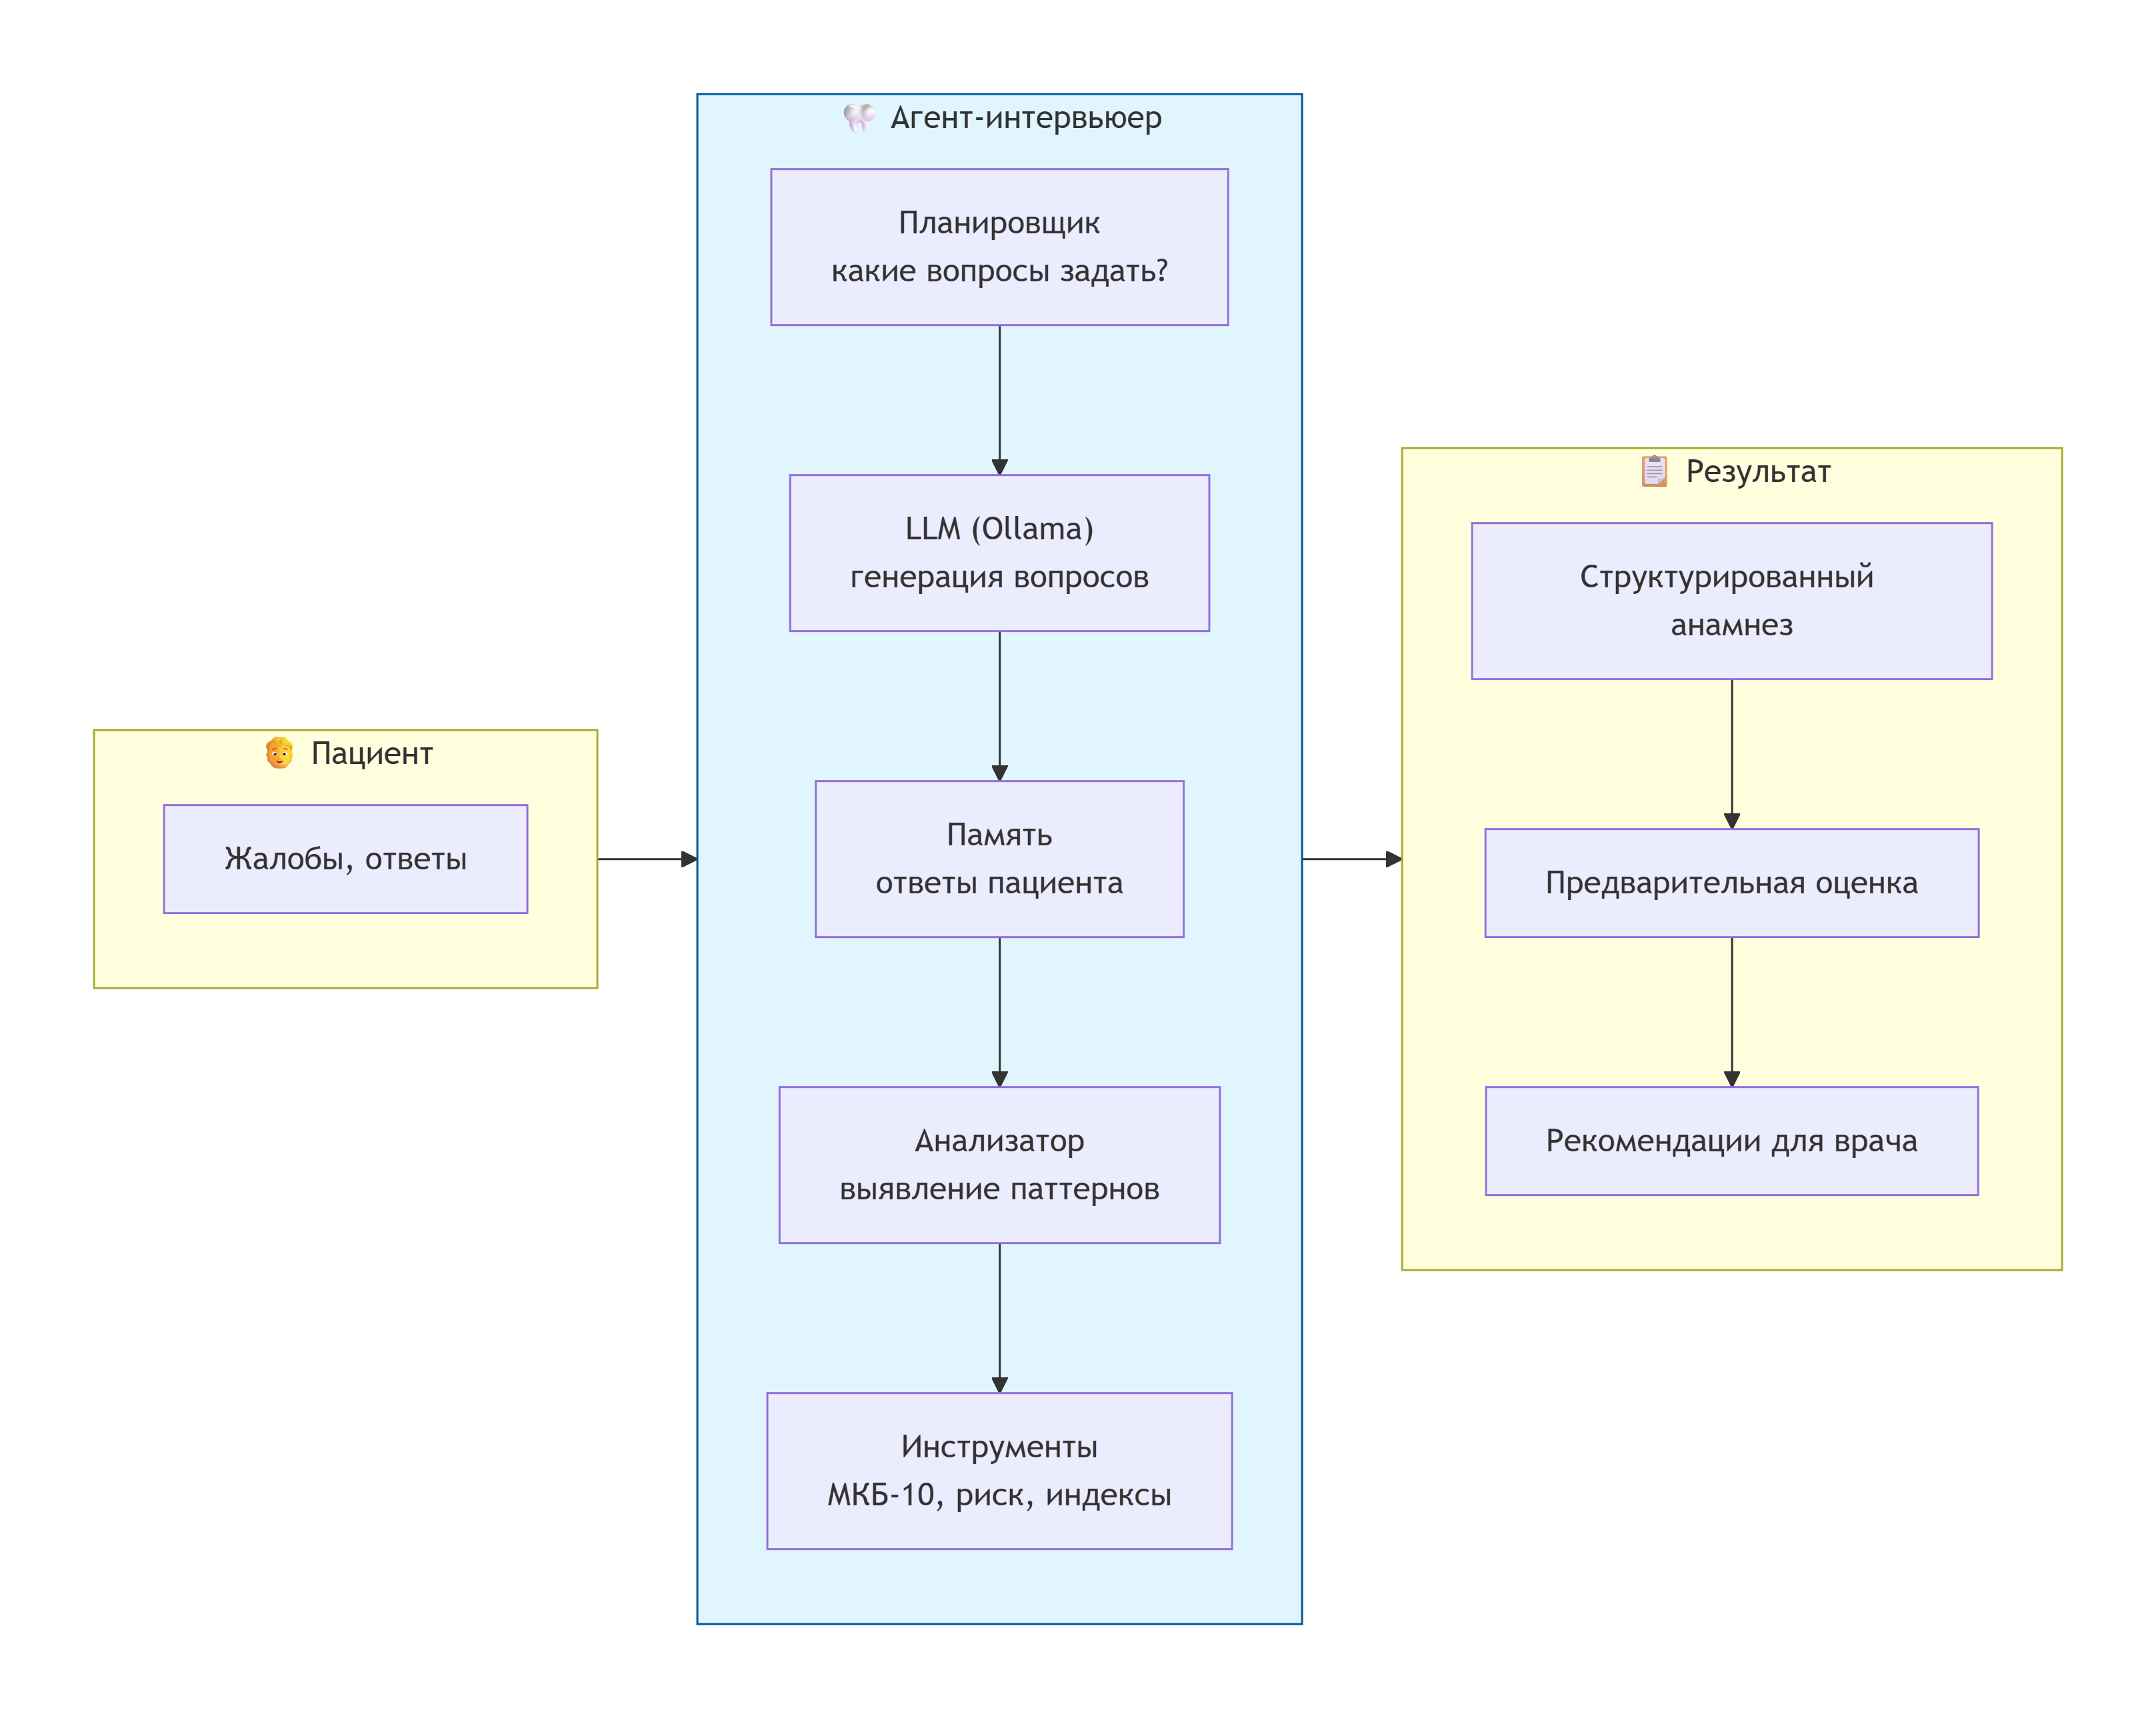


**Пояснение к схеме:**

1. **Планировщик** – определяет, какие вопросы задать на основе предыдущих ответов (например, если пациент упомянул боль при накусывании, следующим будет вопрос о перкуссии и рентгене).
2. **LLM** – генерирует эмпатичные, профессиональные вопросы на русском языке.
3. **Память** – сохраняет все ответы пациента (жалобы, аллергологический анамнез, принимаемые препараты).
4. **Анализатор** – выявляет паттерны (например, признаки острого воспаления, риски кровотечения).
5. **Инструменты** – вызывает расчет индексов, проверяет критерии МКБ-10, оценивает риски.

---

## 4.3. Пример диалога с агентом-интервьюером (стоматологический кейс)

**Этот пример показывает, как агент-интервьюер проводит сбор анамнеза при подозрении на обострение хронического периодонтита:**

```
🦷 Агент: Здравствуйте. Я проведу первичный опрос перед приёмом врача-стоматолога.
         Расскажите, пожалуйста, что вас беспокоит?

🧑 Пациент: У меня болит зуб внизу слева, больно накусывать.

🦷 Агент: [Запоминает: боль при накусывании, нижняя челюсть слева]
         Как давно появилась боль? Она усиливается ночью?

🧑 Пациент: Боль появилась вчера вечером. Ночью спал плохо, боль постоянная.

🦷 Агент: [Запоминает: острая боль, длительность 1 сутки, ночные боли]
         Есть ли припухлость десны или щеки в этой области?

🧑 Пациент: Десна немного припухла, но щека вроде нормальная.

🦷 Агент: [Запоминает: локальная припухлость десны]
         [Вызывает инструмент: оценка риска одонтогенной инфекции]
         [Анализ: локальная припухлость без признаков распространения – риск средний]
         Есть ли у вас аллергия на лекарства?

🧑 Пациент: Да, аллергия на пенициллин.

🦷 Агент: [Запоминает: аллергия на пенициллин (КРИТИЧЕСКИ ВАЖНО)]
         [Вызывает инструмент: проверка совместимости препаратов]
         [Анализ: необходимо избегать назначения пенициллинового ряда]
         Спасибо. Принимаете ли вы препараты, разжижающие кровь?

🧑 Пациент: Да, кардиомагнил каждый день.

🦷 Агент: [Запоминает: прием антиагрегантов (кардиомагнил)]
         [Вызывает инструмент: оценка риска кровотечения]
         [Анализ: риск кровотечения при инвазивных манипуляциях повышен]
         Я подготовлю структурированный анамнез для врача.
```

**Что мы видим в этом диалоге:**

| Действие агента | Что это значит для стоматолога |
|-----------------|------------------------------|
| Запоминает жалобы | Формирует базу для диагностики |
| Адаптирует вопросы | Следует алгоритму обследования |
| Вызывает инструменты | Оценивает риск инфекции и кровотечения |
| Фиксирует аллергию | Критически важная информация для назначения терапии |
| Структурирует результат | Готовый анамнез для врача перед началом приёма |

---

## 4.4. Схема: процесс сбора анамнеза агентом (стоматологический профиль)


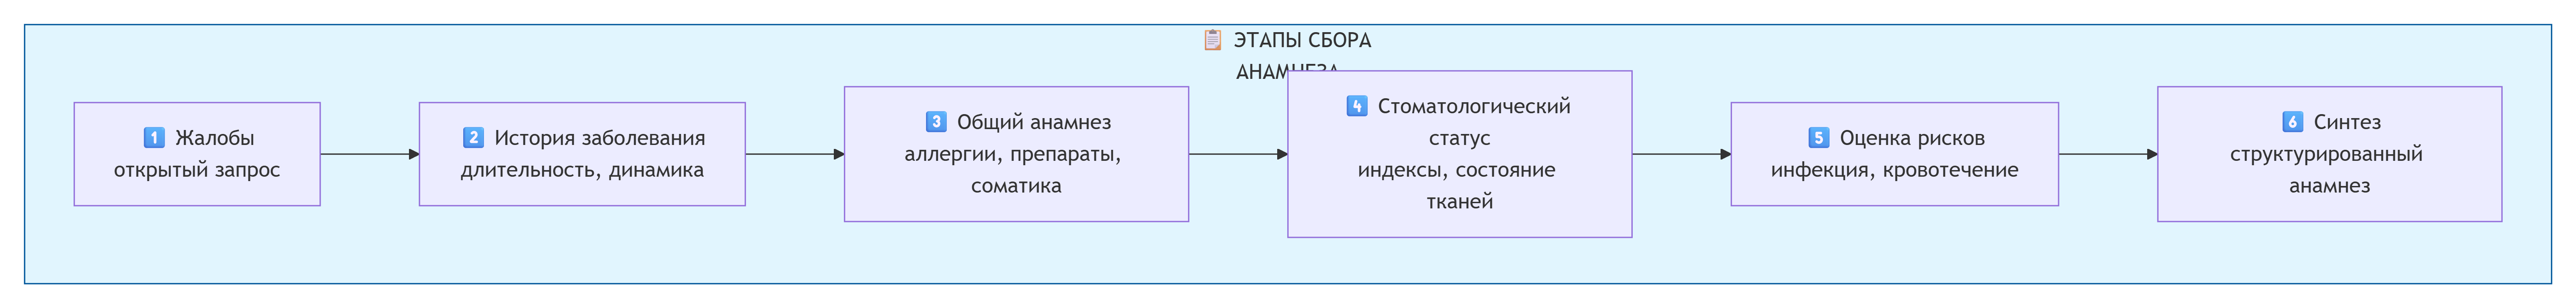


**Пояснение к этапам:**

1. **Жалобы** – открытый запрос, позволяющий пациенту описать проблему своими словами.
2. **История заболевания** – уточнение длительности, интенсивности, провоцирующих факторов (реакция на холодное/горячее, при накусывании, ночные боли).
3. **Общий анамнез** – выявление аллергий, принимаемых препаратов, соматических заболеваний (диабет, сердечно-сосудистые, эндокринные).
4. **Стоматологический статус** – использование индексов (OHI-S, CPITN), оценка состояния слизистой, пародонта, зубных рядов.
5. **Оценка рисков** – выявление признаков одонтогенной инфекции, риска кровотечения, риска неотложных состояний.
6. **Синтез** – формирование структурированного анамнеза с предварительными выводами.

---

## 4.5. Полный код агента-интервьюера с системным промптом (стоматологический профиль)

**Что делает этот код:** Создаёт расширенную версию агента-интервьюера с кастомным системным промптом, настроенным на стоматологическую практику.

**Для ординатора это означает:** Вы можете настроить поведение агента под свой клинический подход – задать структуру опроса, правила реагирования на риски, стиль общения с пациентом.

```python
# ============================================================
# ПОЛНЫЙ КОД: АГЕНТ-ИНТЕРВЬЮЕР С СИСТЕМНЫМ ПРОМПТОМ (СТОМАТОЛОГИЯ)
# ============================================================

import os
import time
import warnings
warnings.filterwarnings('ignore')

# 1-5. (Установка окружения аналогично предыдущему коду. Для краткости опущено)
# Предполагаем, что Ollama запущен, модель загружена, библиотеки установлены.

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import initialize_agent, AgentType

llm = ChatOllama(model="llama3.1:8b", temperature=0.4)

# Инструменты (адаптированы под стоматологию)
@tool
def search_icd10(query: str) -> str:
    """Поиск диагностических критериев в МКБ-10 по симптомам."""
    return f"📖 По запросу '{query}' в МКБ-10: К04.5 Хронический апикальный периодонтит (признаки: боль при накусывании, периапикальные изменения на рентгене). К04.0 Пульпит (ночные боли, реакция на температурные раздражители)."

@tool
def assess_infection_risk(text: str) -> str:
    """Оценка риска одонтогенной инфекции (флегмона, абсцесс)."""
    high_risk = ["отек щеки", "тризм", "дисфагия", "температура 38", "распространение отека"]
    moderate_risk = ["припухлость десны", "локальный отек", "боль при глотании"]
    text_lower = text.lower()
    if any(kw in text_lower for kw in high_risk):
        return "🔴 ВЫСОКИЙ РИСК! Признаки распространенной одонтогенной инфекции. Требуется срочный осмотр хирурга."
    elif any(kw in text_lower for kw in moderate_risk):
        return "🟡 УМЕРЕННЫЙ РИСК. Локальный воспалительный процесс. Рекомендована консультация стоматолога-хирурга."
    return "🟢 РИСК НИЗКИЙ."

@tool
def check_drug_interactions(medications: str) -> str:
    """Проверка взаимодействия препаратов с антикоагулянтами/антиагрегантами."""
    if "кардиомагнил" in medications.lower() or "аспирин" in medications.lower():
        return "⚠️ Пациент принимает антиагрегант (аспирин/кардиомагнил). Риск кровотечения при инвазивных манипуляциях."
    if "варфарин" in medications.lower():
        return "🔴 Пациент принимает варфарин. Требуется консультация кардиолога перед инвазивными процедурами!"
    return "✅ Прием препаратов, влияющих на свертываемость, не выявлен."

tools = [search_icd10, assess_infection_risk, check_drug_interactions]

# Память и системный промпт
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

SYSTEM_PROMPT = """Ты – профессиональный ассистент врача-стоматолога. Твоя задача – собрать структурированный стоматологический анамнез.

Твои правила:
1. Задавай один вопрос за раз.
2. Запоминай все ответы пациента (жалобы, аллергии, препараты).
3. Используй инструменты для проверки симптомов по МКБ-10, оценки риска инфекции и проверки лекарственных взаимодействий.
4. Если выявляешь высокий риск – немедленно реагируй на это в ответе (рекомендуй срочный осмотр).
5. После сбора основных данных – дай предварительную оценку и рекомендации.
6. Будь эмпатичным, поддерживающим и профессиональным.

⚠️ КРИТИЧЕСКИ ВАЖНО: Все твои мысли (Thought) и входные данные для инструментов (action_input) должны быть СТРОГО НА РУССКОМ ЯЗЫКЕ.
Никогда не переводи симптомы на другой язык при вызове инструментов! Отвечай пациенту ТОЛЬКО на русском."""

print("\n⏳ Инициализация агента-интервьюера...")
agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=5,
    handle_parsing_errors=True,
    agent_kwargs={"prefix": SYSTEM_PROMPT}
)
print("✅ Агент-интервьюер создан!")

# Функция общения
def chat(patient_text: str):
    print("\n" + "=" * 60)
    print(f"🧑 Пациент: {patient_text}")
    print("-" * 60)
    response = agent.invoke({"input": patient_text})
    final_answer = response.get("output", "Ошибка генерации")
    print(f"🦷 Интервьюер: {final_answer}")
    print("=" * 60)
    return final_answer

# Тестовый прогон (клинический сценарий: обострение хронического периодонтита)
print("\n📋 КЛИНИЧЕСКИЙ СЦЕНАРИЙ: ОБОСТРЕНИЕ ХРОНИЧЕСКОГО ПЕРИОДОНТИТА")
print("=" * 60)
memory.clear()

chat("Здравствуйте. У меня болит зуб, больно жевать, появилась припухлость десны.")
chat("Боль началась вчера, ночью усилилась. Температуры вроде нет, но чувствую себя разбитым.")
chat("Я принимаю кардиомагнил каждый день. И у меня аллергия на пенициллин.")

# Интерактивный режим
print("\n" + "=" * 60)
print("🎤 ИНТЕРАКТИВНЫЙ РЕЖИМ (Вы можете продолжить опрос)")
print("=" * 60)
print("💡 Введите 'стоп' для завершения.")

try:
    while True:
        user_input = input("\n🧑 Вы (пациент): ")
        if user_input.lower() in ["стоп", "выход", "stop", "exit"]:
            print("\n🦷 Интервьюер: Спасибо. Анамнез сформирован.")
            break
        if not user_input.strip():
            continue
        chat(user_input)
except EOFError:
    print("\n⚠️ Интерактивный режим недоступен в данной среде.")
```

---

## 4.6. Пояснение к системному промпту

**Что такое системный промпт и зачем он нужен?**

**Системный промпт** – это инструкция, которая задаёт модели **роль, стиль и правила поведения** на протяжении всего диалога. В отличие от обычного запроса (который меняется каждый раз), системный промпт действует постоянно.

**Интуитивная аналогия из стоматологической практики:**

> Представьте, что вы – заведующий отделением, и перед началом приёма вы даёте ординатору установку:
> - «Ты – ассистент, а не лечащий врач».
> - «Твоя задача – собрать полный анамнез, а не ставить окончательный диагноз».
> - «Если пациент сообщает о тризме или распространенном отеке – немедленно вызывай хирурга».
> - «Обязательно спроси про аллергию на антибиотики и прием антикоагулянтов».
>
> Это и есть системный промпт. Он задаёт **рамки** работы агента.

**Почему системный промпт важен для агента-интервьюера:**

| Без системного промпта | С системным промптом |
|------------------------|----------------------|
| Модель может давать рекомендации по лечению | Модель знает свою роль (сбор анамнеза) |
| Может забывать спросить про аллергии | Помнит структуру опроса (обязательные вопросы) |
| Может игнорировать риски | Реагирует на риски по правилам (тризм → срочный осмотр) |
| Ответы непредсказуемы | Ответы последовательны и стандартизированы |

**Структура системного промпта в коде:**

```python
SYSTEM_PROMPT = """
Роль: [кем является агент]
Задача: [что должен делать]
Правила: [что можно и что нельзя]
Инструменты: [какие инструменты доступны]
Стиль: [как должен общаться]
"""
```

**Как адаптировать системный промпт под свой подход:**

| Что изменить | Как изменить | Пример для стоматологии |
|--------------|--------------|------------------------|
| Роль | Задать другую роль | "Ты – ассистент хирурга-стоматолога" |
| Правила | Добавить или убрать правила | "При подозрении на флегмону – немедленно рекомендовать госпитализацию" |
| Стиль | Изменить тон | "Будь строгим и директивным при сообщении о рисках" |
| Инструменты | Добавить новые | "Расчет индекса КПУ", "Оценка степени подвижности зубов" |

---

## 4.7. Как адаптировать агента под узкие специальности

Учитывая, что в группе обучаются ординаторы разных профилей, один и тот же агентский фреймворк может быть адаптирован:

| Специальность ординатора | Адаптация агента | Пример инструментов |
|--------------------------|------------------|---------------------|
| **Стоматолог-терапевт** | Агент для сбора анамнеза, дифференциальной диагностики, плана лечения | МКБ-10, риск инфекции, индексы |
| **Рентгенолог** | Агент для анализа описаний снимков, выявления паттернов | Анализ паттернов, рекомендация доп. методов |
| **Микробиолог** | Агент для интерпретации посевов, антибиотикограмм | Анализ резистентности, рекомендация антибиотиков |
| **Неонатолог** | Агент для консультаций по стоматологическому здоровью беременных | Оценка рисков для плода, профилактика |

**Пример адаптации для микробиолога:**

```python
@tool
def interpret_culture_report(report: str) -> str:
    """Интерпретация результатов бактериологического посева из пародонтального кармана."""
    if "Porphyromonas gingivalis" in report:
        return "🦠 Выявлен P. gingivalis – пародонтопатоген. Рекомендуется метронидазол + амоксициллин (при отсутствии аллергии)."
    if "Staphylococcus aureus (MRSA)" in report:
        return "🔴 Выявлен MRSA! Требуется консультация клинического микробиолога. Ограниченный выбор антибиотиков."
    return "🦠 Патогенной микрофлоры не выявлено."
```

---

## 4.8. Полный самодостаточный код (все в одном файле)

**Что делает этот код:** Это полноценный, самодостаточный файл для запуска в Google Colab. Он включает установку Ollama, загрузку модели, настройку агента с инструментами и интерактивный режим. Код адаптирован под стоматологическую практику.

```python
# ============================================================
# ПОЛНЫЙ КОД: АГЕНТ-ИНТЕРВЬЮЕР (ИНТЕРАКТИВНЫЙ, СТОМАТОЛОГИЯ, COLAB 2026)
# ============================================================

import os
import time
import sys
import warnings
warnings.filterwarnings('ignore')

# 1. СИСТЕМНЫЕ ЗАВИСИМОСТИ И УСТАНОВКА OLLAMA
!rm -rf /usr/local/lib/ollama /usr/local/bin/ollama
!apt-get update -qq > /dev/null 2>&1 && apt-get install -y zstd wget -qq > /dev/null 2>&1

OLLAMA_URL = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64.tar.zst"
ARCHIVE_PATH = "/tmp/ollama-linux-amd64.tar.zst"

print("⏳ Скачивание бинарников Ollama напрямую с GitHub...")
ollama_installed = False

for attempt in range(5):
    if os.path.exists(ARCHIVE_PATH):
        os.remove(ARCHIVE_PATH)
    !wget -q --tries=5 --timeout=20 --show-progress -O {ARCHIVE_PATH} {OLLAMA_URL}
    if os.path.exists(ARCHIVE_PATH) and os.path.getsize(ARCHIVE_PATH) > 1000000:
        print(f"✅ Архив успешно скачан!")
        break
    else:
        print(f"⚠️ Ошибка сети. Повторная попытка {attempt+1}/5 через 5 сек...")
        time.sleep(5)
else:
    raise Exception("❌ Не удалось скачать Ollama.")

print("⏳ Распаковка и установка...")
!tar -xf {ARCHIVE_PATH} -C /usr/local/
!chmod +x /usr/local/bin/ollama

if os.path.exists('/usr/local/bin/ollama'):
    print("✅ Ollama успешно установлен!")

# 2. ЗАПУСК СЕРВЕРА OLLAMA
import subprocess
import urllib.request
import urllib.error
import socket

print("\n⏳ Запуск сервера Ollama...")
with open("/tmp/ollama.log", "w") as log_file:
    subprocess.Popen(["ollama", "serve"], stdout=log_file, stderr=log_file)

time.sleep(3)

server_ready = False
for i in range(40):
    try:
        req = urllib.request.urlopen("http://localhost:11434/api/tags", timeout=2)
        if req.getcode() == 200:
            server_ready = True
            break
    except (urllib.error.URLError, TimeoutError, socket.timeout, OSError):
        time.sleep(1)

if not server_ready:
    raise Exception("❌ Сервер Ollama не запустился!")
print("✅ Ollama запущен и готов к работе!")

# 3. СКАЧИВАНИЕ МОДЕЛИ
MODEL_NAME = "llama3.1:8b"
print(f"\n⏳ Скачивание модели {MODEL_NAME} (около 4.7 ГБ)...")
subprocess.run(["ollama", "pull", MODEL_NAME])
print(f"🎉 Модель {MODEL_NAME} загружена!")

# 4. УСТАНОВКА PYTHON БИБЛИОТЕК
print("\n⏳ Установка Python библиотек...")
!pip install langchain langchain-core langchain-community langchain-ollama langchain-classic -q > /dev/null
print("✅ Библиотеки установлены!")

# 5. ИМПОРТЫ И НАСТРОЙКА LLM
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import initialize_agent, AgentType

print("⏳ Загрузка модели...")
llm = ChatOllama(model=MODEL_NAME, temperature=0.4)
print("✅ Модель загружена!")

# 6. ОПРЕДЕЛЕНИЕ ИНСТРУМЕНТОВ (СТОМАТОЛОГИЧЕСКИЙ ПРОФИЛЬ)
@tool
def search_icd10(query: str) -> str:
    """Поиск диагностических критериев в МКБ-10.
    ВНИМАНИЕ: Аргумент 'query' должен быть ОБЫЧНОЙ СТРОКОЙ. НЕ передавай JSON."""
    return f"""📖 По запросу '{query}' найдено в МКБ-10:
    К04.5 Хронический апикальный периодонтит (боль при накусывании, периапикальные изменения)
    К04.0 Пульпит (ночные боли, реакция на температурные раздражители)
    К02.1 Кариес дентина (боли от сладкого, холодного)
    K05.1 Хронический пародонтит (кровоточивость, подвижность зубов)"""

@tool
def assess_infection_risk(text: str) -> str:
    """Оценка риска одонтогенной инфекции.
    ВНИМАНИЕ: Аргумент 'text' должен быть ОБЫЧНОЙ СТРОКОЙ."""
    text_lower = text.lower()
    if any(kw in text_lower for kw in ["отек щеки", "тризм", "дисфагия", "температура", "распростран"]):
        return "🔴 ВЫСОКИЙ РИСК! Признаки распространенной одонтогенной инфекции. Требуется срочный осмотр."
    if any(kw in text_lower for kw in ["припухлость", "отек десны", "локальный"]):
        return "🟡 УМЕРЕННЫЙ РИСК. Локальный воспалительный процесс."
    return "🟢 РИСК НИЗКИЙ."

@tool
def check_drug_interactions(medications: str) -> str:
    """Проверка взаимодействия с антикоагулянтами/антиагрегантами.
    ВНИМАНИЕ: Аргумент 'medications' должен быть ОБЫЧНОЙ СТРОКОЙ."""
    if "варфарин" in medications.lower():
        return "🔴 Пациент принимает варфарин! Требуется консультация кардиолога перед инвазивными процедурами."
    if "кардиомагнил" in medications.lower() or "аспирин" in medications.lower():
        return "⚠️ Пациент принимает антиагреганты. Риск кровотечения при инвазивных манипуляциях."
    return "✅ Прием препаратов, влияющих на свертываемость, не выявлен."

tools = [search_icd10, assess_infection_risk, check_drug_interactions]

# 7. ПАМЯТЬ И СИСТЕМНЫЙ ПРОМПТ
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

SYSTEM_PROMPT = """Ты – ассистент врача-стоматолога. Твоя задача – собрать структурированный анамнез.

Правила:
1. Задавай один вопрос за раз.
2. Запоминай все ответы пациента.
3. Используй инструменты для проверки симптомов, оценки риска и проверки лекарств.
4. Если выявляешь высокий риск – немедленно реагируй.
5. После сбора 4-5 симптомов – дай предварительную оценку.
6. Будь эмпатичным и профессиональным.

⚠️ КРИТИЧЕСКИ ВАЖНО: Все входные данные для инструментов (action_input) должны быть СТРОГО НА РУССКОМ ЯЗЫКЕ.
'Входные данные действия' (action_input) ВСЕГДА должны быть ПРОСТОЙ СТРОКОЙ.
ЗАПРЕЩЕНО передавать JSON-объекты или словари!

Инструменты:
- search_icd10: поиск критериев МКБ-10
- assess_infection_risk: оценка риска инфекции
- check_drug_interactions: проверка лекарственных взаимодействий
"""

# 8. СОЗДАНИЕ АГЕНТА
print("\n⏳ Инициализация агента...")
agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=5,
    handle_parsing_errors=True,
    agent_kwargs={"prefix": SYSTEM_PROMPT}
)
print("✅ Агент-интервьюер создан!")

# 9. ФУНКЦИЯ ОБЩЕНИЯ
def chat(user_input: str):
    response = agent.invoke({"input": user_input})
    return response.get("output", "Ошибка генерации")

# 10. АВТОМАТИЧЕСКИЙ ТЕСТОВЫЙ ПРОГОН
print("\n" + "=" * 60)
print("🦷 АВТОМАТИЧЕСКИЙ ТЕСТОВЫЙ ПРОГОН (СТОМАТОЛОГИЧЕСКИЙ КЕЙС)")
print("=" * 60)
memory.clear()

test_prompts = [
    "Здравствуйте, доктор. У меня болит зуб внизу слева, больно накусывать.",
    "Боль началась вчера, ночью усилилась. Десна припухла.",
    "Я принимаю кардиомагнил и у меня аллергия на пенициллин."
]

for prompt in test_prompts:
    print(f"\n🧑 Пациент: {prompt}")
    print("-" * 40)
    reply = chat(prompt)
    print(f"🦷 Интервьюер: {reply}")

# 11. ИНТЕРАКТИВНОЕ ИНТЕРВЬЮ
def run_interview():
    print("\n" + "=" * 60)
    print("🎤 ИНТЕРАКТИВНЫЙ ОПРОС")
    print("=" * 60)
    print("💡 Введите 'стоп' для завершения")
    print("-" * 60)

    try:
        while True:
            user_input = input("\n🧑 Пациент: ")
            if user_input.lower() in ["стоп", "выход", "exit", "quit"]:
                print("\n🦷 Интервьюер: Спасибо. Анамнез сформирован.")
                break
            if not user_input.strip():
                print("⚠️ Пожалуйста, введите текст.")
                continue
            print("-" * 40)
            reply = chat(user_input)
            print(f"🦷 Интервьюер: {reply}")

    except EOFError:
        print("\n⚠️ Интерактивный режим недоступен.")
    except KeyboardInterrupt:
        print("\n\n🦷 Интервьюер: Сессия прервана пользователем.")

run_interview()
```


# 5. МУЛЬТИАГЕНТНЫЕ СИСТЕМЫ: КООПЕРАЦИЯ АГЕНТОВ В СТОМАТОЛОГИИ

---

## 5.1. Что такое мультиагентная система

**Мультиагентная система (Multi-Agent System, MAS)** – это система из **нескольких агентов**, каждый из которых специализируется на своей задаче. Агенты **общаются** друг с другом, **обмениваются** информацией и **координируют** свои действия с помощью **LangGraph**.

**Интуитивная аналогия из стоматологической клиники:**

> Представьте **многопрофильный стоматологический центр**, где работают разные специалисты:
> - **Стоматолог-терапевт** – проводит осмотр, собирает жалобы.
> - **Рентгенолог** – анализирует снимки (ОПТГ, КЛКТ).
> - **Микробиолог** – интерпретирует посевы.
> - **Хирург** – оценивает необходимость хирургического вмешательства.
> - **Супервизор (зав. отделением)** – координирует работу, контролирует качество.
>
> Каждый специалист – **эксперт** в своей области. Они **передают** информацию друг другу. Вместе они работают **эффективнее**, чем один универсал.

**Когда использовать мультиагентные системы в стоматологии:**

| Ситуация | Почему MAS |
|----------|------------|
| **Комплексная диагностика** | Требуются данные осмотра, рентгена, микробиологии |
| **Планирование сложного лечения** | Нужны мнения разных специалистов (ортопед, хирург, ортодонт) |
| **Оценка рисков** | Разные агенты оценивают разные типы рисков (инфекция, кровотечение, неотложные состояния) |
| **Контроль качества** | Супервизор проверяет работу других агентов |

---

## 5.2. Код: Мультиагентная система с LangGraph (стоматологический консилиум)

**Что делает этот код:** Создаёт мультиагентную систему с четырьмя специализированными агентами: Стоматолог-интервьюер → Диагност → Рентгенолог-ассистент → Супервизор. Каждый агент — отдельный узел в графе LangGraph.

**Для ординатора это означает:** Вы можете создать систему, имитирующую междисциплинарный консилиум для сложных клинических случаев.

```python
# ============================================================
# ПОЛНЫЙ КОД: МУЛЬТИАГЕНТНАЯ СИСТЕМА НА LANGGRAPH (СТОМАТОЛОГИЯ)
# ============================================================
# 4 агента в графе: Интервьюер → Диагност → Рентгенолог → Супервизор
# ============================================================

import os
import time
import warnings
import socket
import subprocess
import urllib.request
import urllib.error

warnings.filterwarnings('ignore')

# 1-3. (Установка Ollama и модели аналогично предыдущим кодам. Опущено для краткости)

from typing import TypedDict, List, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

# 4. ЗАГРУЗКА LLM
llm = ChatOllama(model="llama3.1:8b", temperature=0.3)

# 5. ОПРЕДЕЛЕНИЕ СОСТОЯНИЯ ГРАФА
class DentalAssessmentState(TypedDict):
    patient_text: str
    findings: Annotated[List[str], operator.add]
    risk_level: str
    recommendations: str

# ============================================================
# 6. АГЕНТ-ИНТЕРВЬЮЕР (Стоматолог-терапевт)
# ============================================================
def interviewer(state: DentalAssessmentState) -> dict:
    """Извлекает ключевые жалобы и симптомы из текста пациента"""
    print("\n🦷 [Стоматолог-интервьюер] Анализирую жалобы пациента...")

    prompt = f"""Ты — стоматолог-терапевт. Извлеки из текста пациента ключевые жалобы и симптомы.
Верни ТОЛЬКО список симптомов, каждый с новой строки, начинающийся с "• ".
Без вступлений и пояснений.

Текст пациента: {state['patient_text']}

Симптомы:"""

    try:
        response = llm.invoke(prompt)
        symptoms_text = response.content.strip()
        symptoms = [s.strip() for s in symptoms_text.split('\n') if s.strip().startswith('•')]
        if not symptoms:
            symptoms = [symptoms_text]
    except Exception as e:
        print(f"   ⚠️ Ошибка LLM: {e}")
        symptoms = ["Не удалось извлечь симптомы"]

    print(f"   ✅ Найдено симптомов: {len(symptoms)}")
    return {"findings": [f"🦷 Интервьюер: {s.lstrip('• ')}" for s in symptoms]}

# ============================================================
# 7. АГЕНТ-ДИАГНОСТ
# ============================================================
def diagnostician(state: DentalAssessmentState) -> dict:
    """Сопоставляет симптомы с нозологиями по МКБ-10"""
    print("\n🔍 [Диагност] Формулирую диагностические гипотезы...")

    findings_text = "\n".join(state.get('findings', []))

    prompt = f"""Ты — стоматолог-диагност. На основе выявленных симптомов определи:
1. Наиболее вероятный диагноз (пульпит, периодонтит, кариес, пародонтит и т.д.)
2. Какие дифференциальные диагнозы следует исключить

Верни ТОЛЬКО 2-3 строки с выводами, каждая с новой строки, начинающиеся с "• ".

Симптомы:
{findings_text}

Текст пациента: {state['patient_text']}

Диагноз:"""

    try:
        response = llm.invoke(prompt)
        diagnoses = [f"🔍 Диагност: {line.strip().lstrip('• ')}"
                    for line in response.content.strip().split('\n')
                    if line.strip()]
    except Exception as e:
        print(f"   ⚠️ Ошибка LLM: {e}")
        diagnoses = ["Не удалось сформулировать диагноз"]

    print(f"   ✅ Сформулировано гипотез: {len(diagnoses)}")
    return {"findings": diagnoses}

# ============================================================
# 8. АГЕНТ-РЕНТГЕНОЛОГ (Ассистент рентгенолога)
# ============================================================
def radiologist(state: DentalAssessmentState) -> dict:
    """Оценивает необходимость и интерпретацию рентгенологических данных"""
    print("\n🩻 [Рентгенолог] Оцениваю необходимость визуализации...")

    findings_text = "\n".join(state.get('findings', []))

    prompt = f"""Ты — рентгенолог. На основе клинических данных определи:
1. Какие рентгенологические исследования показаны (прицельный снимок, ОПТГ, КЛКТ)
2. Какие изменения могут быть выявлены при данном диагнозе

Верни ТОЛЬКО 2-3 строки, каждая с новой строки, начинающиеся с "• ".

Клинические данные:
{findings_text}

Рентгенологическая оценка:"""

    try:
        response = llm.invoke(prompt)
        rad_findings = [f"🩻 Рентгенолог: {line.strip().lstrip('• ')}"
                  for line in response.content.strip().split('\n')
                  if line.strip()]
    except Exception as e:
        print(f"   ⚠️ Ошибка LLM: {e}")
        rad_findings = ["Не удалось сформировать рентгенологическую оценку"]

    print(f"   ✅ Рентгенологическая оценка сформирована")
    return {"findings": rad_findings}

# ============================================================
# 9. АГЕНТ-СУПЕРВИЗОР
# ============================================================
def supervisor(state: DentalAssessmentState) -> dict:
    """Формирует итоговое заключение и рекомендации по тактике лечения"""
    print("\n👨‍⚕️ [Супервизор] Формирую итоговое заключение...")

    patient_text = state.get('patient_text', '')
    findings_text = "\n".join(state.get('findings', []))

    # Оценка риска одонтогенной инфекции
    high_risk_keywords = ["отек щеки", "тризм", "дисфагия", "температура", "распростран"]
    moderate_risk_keywords = ["припухлость", "локальный отек", "боль при глотании"]

    text_lower = patient_text.lower()
    if any(kw in text_lower for kw in high_risk_keywords):
        risk_level = "🔴 ВЫСОКИЙ"
    elif any(kw in text_lower for kw in moderate_risk_keywords):
        risk_level = "🟡 УМЕРЕННЫЙ"
    else:
        risk_level = "🟢 НИЗКИЙ"

    prompt = f"""Ты — заведующий стоматологическим отделением (супервизор). На основе полной диагностики сформируй финальное заключение.

Уровень риска: {risk_level}

Полная история диагностики:
{findings_text}

Дай профессиональное заключение (2-4 предложения):
1. Предварительный диагноз
2. Рекомендуемый план лечения (терапия, хирургия, ортопедия)
3. Необходимость дополнительных консультаций

Заключение:"""

    try:
        response = llm.invoke(prompt)
        final_recommendation = response.content.strip()
    except Exception as e:
        print(f"   ⚠️ Ошибка LLM: {e}")
        final_recommendation = "Не удалось сформировать заключение"

    print(f"   ✅ Заключение сформировано")
    return {
        "risk_level": risk_level,
        "recommendations": final_recommendation
    }

# ============================================================
# 10. ПОСТРОЕНИЕ ГРАФА LANGGRAPH
# ============================================================
print("\n⏳ Построение мультиагентного графа...")
workflow = StateGraph(DentalAssessmentState)

# Добавляем узлы (агентов)
workflow.add_node("interviewer", interviewer)
workflow.add_node("diagnostician", diagnostician)
workflow.add_node("radiologist", radiologist)
workflow.add_node("supervisor", supervisor)

# Определяем последовательность
workflow.add_edge(START, "interviewer")
workflow.add_edge("interviewer", "diagnostician")
workflow.add_edge("diagnostician", "radiologist")
workflow.add_edge("radiologist", "supervisor")
workflow.add_edge("supervisor", END)

# Компилируем граф
app = workflow.compile()
print("✅ Мультиагентная система готова!")

# ============================================================
# 11. ФУНКЦИЯ ЗАПУСКА ДИАГНОСТИКИ
# ============================================================
def run_diagnosis(patient_text: str):
    """Запускает полную мультиагентную диагностику"""
    print("\n" + "=" * 70)
    print("🦷 МУЛЬТИАГЕНТНАЯ ДИАГНОСТИКА (СТОМАТОЛОГИЧЕСКИЙ КОНСИЛИУМ)")
    print("=" * 70)
    print(f"📝 Текст пациента:\n   {patient_text}")
    print("-" * 70)

    initial_state = {
        "patient_text": patient_text,
        "findings": [],
        "risk_level": "❓ НЕИЗВЕСТНО",
        "recommendations": ""
    }

    try:
        result = app.invoke(initial_state)
    except Exception as e:
        print(f"❌ Ошибка выполнения графа: {e}")
        return None

    print("\n" + "=" * 70)
    print("📋 ИТОГОВЫЙ ДИАГНОСТИЧЕСКИЙ ОТЧЁТ")
    print("=" * 70)

    print("\n🔍 ИСТОРИЯ ДИАГНОСТИКИ (по агентам):")
    for i, finding in enumerate(result['findings'], 1):
        print(f"   {i}. {finding}")

    print(f"\n📊 УРОВЕНЬ РИСКА: {result['risk_level']}")
    print(f"\n💊 ИТОГОВАЯ РЕКОМЕНДАЦИЯ СУПЕРВИЗОРА:")
    print(f"   {result['recommendations']}")
    print("=" * 70)

    return result

# ============================================================
# 12. ТЕСТОВЫЕ ЗАПУСКИ (КЛИНИЧЕСКИЕ СЦЕНАРИИ)
# ============================================================

print("\n\n" + "🎬 ТЕСТ №1: ОБОСТРЕНИЕ ХРОНИЧЕСКОГО ПЕРИОДОНТИТА" + "\n")
run_diagnosis("У пациента боль в области 46 зуба при накусывании, припухлость десны. Боль появилась 2 дня назад. На рентгене ранее выявлялось расширение периодонтальной щели. Пациент принимает аспирин.")

print("\n\n" + "🎬 ТЕСТ №2: ОСТРЫЙ ПУЛЬПИТ" + "\n")
run_diagnosis("Острая самопроизвольная боль в 15 зубе, усиливается ночью. Реакция на холодное положительная, длительная. Кариозная полость глубокая, зондирование дна болезненно.")

print("\n\n" + "🎬 ТЕСТ №3: РИСК ФЛЕГМОНЫ (ВЫСОКИЙ)" + "\n")
run_diagnosis("У пациента отек щеки слева, тризм, температура 38.2. Боль при глотании. Состояние ухудшается в течение последних 6 часов. В анамнезе: удаление 38 зуба 3 дня назад.")

print("\n🏁 МУЛЬТИАГЕНТНАЯ ДИАГНОСТИКА ЗАВЕРШЕНА")
```

---

## 5.3. Схема: архитектура мультиагентной системы в LangGraph (стоматологический консилиум)


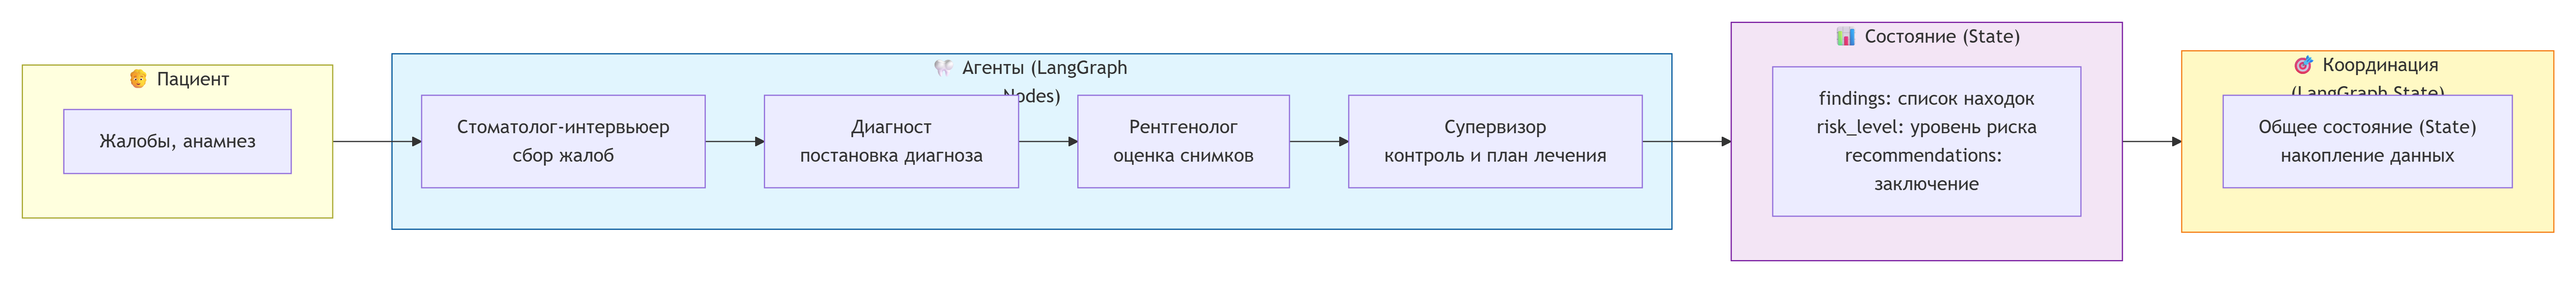


**Пояснение к схеме:**

1. **Пациент** сообщает жалобы.
2. **Стоматолог-интервьюер** извлекает ключевые симптомы.
3. **Диагност** сопоставляет симптомы с нозологиями.
4. **Рентгенолог** оценивает необходимость и интерпретацию визуализации.
5. **Супервизор** формирует итоговое заключение и план лечения.
6. **Состояние** накапливает данные, которые передаются между агентами.

---

## 5.4. Кооперация агентов: опрос + диагностика + рентген + контроль

В мультиагентной системе агенты работают **последовательно**, обмениваясь информацией через **состояние (State)**.

**Пример: система для комплексной диагностики (стоматология)**


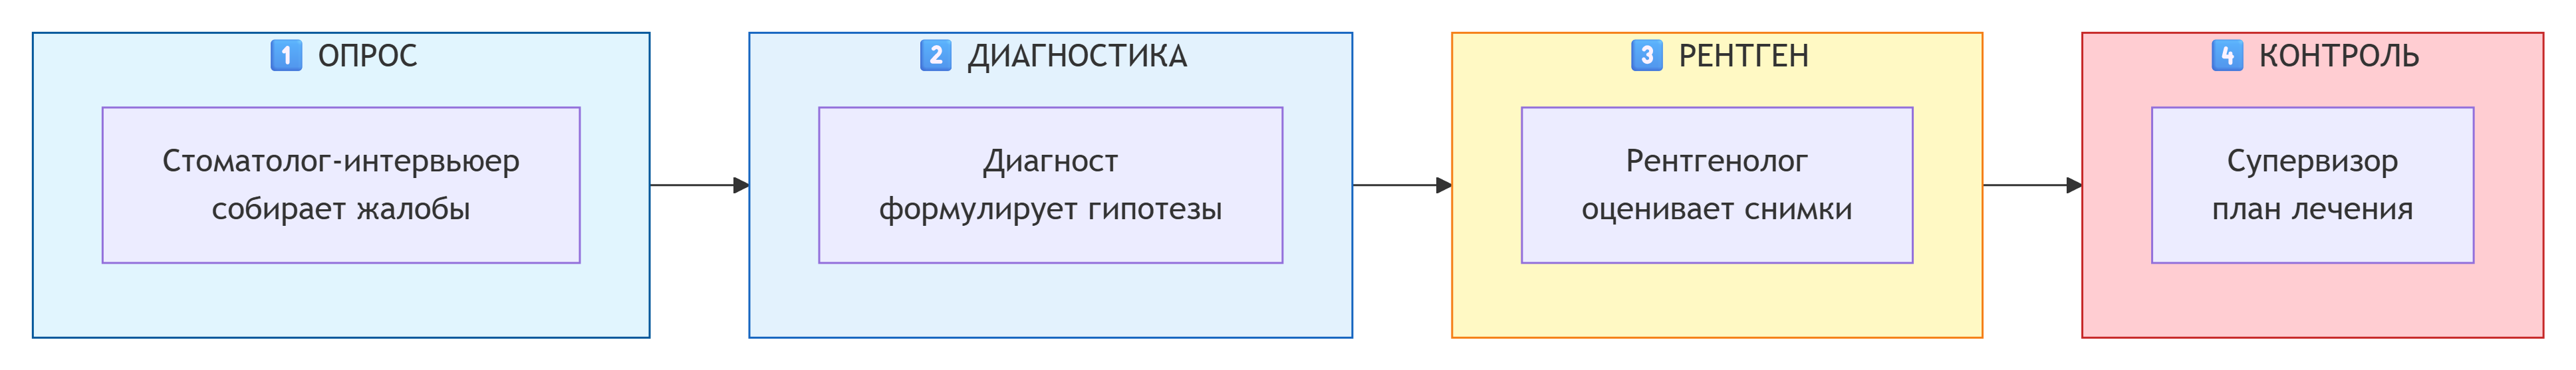



**Что происходит на каждом этапе:**

| Этап | Агент | Что делает | Результат |
|------|-------|------------|-----------|
| 1 | Стоматолог-интервьюер | Извлекает жалобы, анамнез | Структурированные симптомы |
| 2 | Диагност | Сопоставляет с МКБ-10 | Диагностические гипотезы |
| 3 | Рентгенолог | Оценивает визуализацию | Рентгенологические находки |
| 4 | Супервизор | Проверяет качество, формирует план | Итоговое заключение |

---

## 5.5. Сравнение Single Agent и Multi-Agent System

| Критерий | Single Agent | Multi-Agent System |
|----------|--------------|-------------------|
| **Количество агентов** | 1 | 2+ |
| **Специализация** | Универсальный (например, только опрос) | Каждый специализируется (опрос, диагностика, рентген) |
| **Сложность** | Низкая | Высокая |
| **Координация** | Не требуется | LangGraph State |
| **Контроль качества** | Один агент всё контролирует | Супервизор отдельно |
| **Точность** | Средняя | Высокая (за счет специализации) |
| **Когда использовать** | Простые задачи (сбор анамнеза) | Сложные задачи (комплексная диагностика) |
| **Пример в стоматологии** | Первичный опрос пациента | Междисциплинарный консилиум по сложному случаю |

**Когда выбрать Single Agent в стоматологии:**

| Задача | Почему Single Agent |
|--------|---------------------|
| Сбор анамнеза | Простой, линейный процесс |
| Анализ одного снимка | Одна задача, один подход |
| Первичный скрининг | Быстрый, стандартизированный |

**Когда выбрать Multi-Agent System в стоматологии:**

| Задача | Почему Multi-Agent |
|--------|-------------------|
| Комплексная диагностика | Требует данных осмотра, рентгена, микробиологии |
| Планирование имплантации | Нужны мнения хирурга, ортопеда, рентгенолога |
| Оценка риска (инфекция, кровотечение) | Разные агенты оценивают разные риски |
| Лечение заболеваний пародонта | Требуется кооперация пародонтолога, гигиениста, микробиолога |

---

## 5.6. Основные выводы по разделу

1. **LangChain** – фреймворк для создания агентов с памятью и инструментами. Основа для любых агентных систем в стоматологии.

2. **LangGraph** – библиотека для мультиагентных систем с состоянием. Позволяет создавать сложные графы, где агенты обмениваются информацией, имитируя междисциплинарный консилиум.

3. **Single Agent** – один агент для простых задач (сбор анамнеза, анализ снимков). Прост в реализации и отладке.

4. **Multi-Agent System** – команда агентов для сложных задач (комплексная диагностика, планирование лечения). Даёт более высокую точность и контроль качества.

5. **Supervisor Agent** – оркестратор, управляющий работой агентов. Это «заведующий отделением», который решает, кто и когда должен работать.

6. **Состояние (State)** – общий контекст, который передаётся между агентами в LangGraph. Это «медицинская карта», которая хранит всю информацию о пациенте.

7. **Код** – все примеры кода готовы к запуску в Google Colab с использованием Ollama, LangChain и LangGraph. Вы можете скопировать их и адаптировать под свои задачи.


## 6. ТРЕНДЫ 2026: ДОЛГОСРОЧНЫЕ ПЕРСОНАЛИЗИРОВАННЫЕ ПОМОЩНИКИ В СТОМАТОЛОГИИ

---

### 6.1. От одноразовых консультаций к долгосрочному сопровождению пациента

Ключевой тренд 2026 года – переход от **эпизодических** ИИ-консультаций к **долгосрочным персонализированным помощникам**, которые сопровождают пациента на протяжении всего периода лечения и диспансерного наблюдения.

**Интуитивная аналогия:**

> Раньше ИИ-помощник был как **разовая консультация** – пациент пришел, задал вопрос, получил ответ, и все забыто. Теперь ИИ-помощник становится как **личный стоматолог**, который:
> - Помнит историю лечения (какие зубы лечили, какие имплантаты установлены).
> - Отслеживает динамику состояния пародонта (глубина карманов, кровоточивость).
> - Напоминает о профилактических осмотрах и гигиене.
> - Адаптируется к индивидуальным особенностям пациента (аллергии, страхи, предпочтения).

**Почему это важно для стоматологии:**

Традиционное стоматологическое лечение часто **многоэтапное и длительное** (ортодонтическое лечение, имплантация, эндодонтия). Врач должен помнить:
- Какие процедуры проводились ранее.
- Какие материалы использовались.
- Какие реакции наблюдались у пациента.
- Какова динамика заживления.

**ИИ-помощник без долгосрочной памяти** не может этого делать. Он каждый раз начинает «с чистого листа». **Долгосрочный персонализированный помощник** решает эту проблему, сохраняя всю историю взаимодействий.

---

### 6.2. Пример: как выглядит долгосрочное сопровождение пациента

**Сценарий:** пациент проходит ортодонтическое лечение с использованием элайнеров в течение 6 месяцев.

```
📅 Неделя 1 (Установка элайнеров)
🧑 Пациент: Поставили элайнеры, чувствуется давление на зубы.
🦷 Помощник: Запоминаю: начато ортодонтическое лечение. Давление в первые дни – норма. Будем отслеживать адаптацию.

📅 Неделя 2
🧑 Пациент: Давление уменьшилось, но появилось натирание слизистой.
🦷 Помощник: Помню, что вы на 2-й неделе лечения. Натирание может быть связано с краями элайнеров. Рекомендую воск.

📅 Неделя 6
🧑 Пациент: Заметил, что один зуб стал подвижным. Это нормально?
🦷 Помощник: Учитывая, что мы на 6-й неделе активного перемещения, небольшая физиологическая подвижность допустима. Но рекомендую контрольный осмотр ортодонта.

📅 Неделя 12
🧑 Пациент: Был у ортодонта, он сказал, что все идет хорошо.
🦷 Помощник: Отлично! Я вижу, что вы соблюдаете рекомендации. Не забывайте про гигиену элайнеров и полости рта.
```

**Ключевое отличие:** помощник **помнит** прошлые взаимодействия и **использует** их для персонализации. Он отслеживает динамику лечения и дает рекомендации в контексте всей истории.

---

### 6.3. Архитектура долгосрочного персонализированного помощника (стоматология)


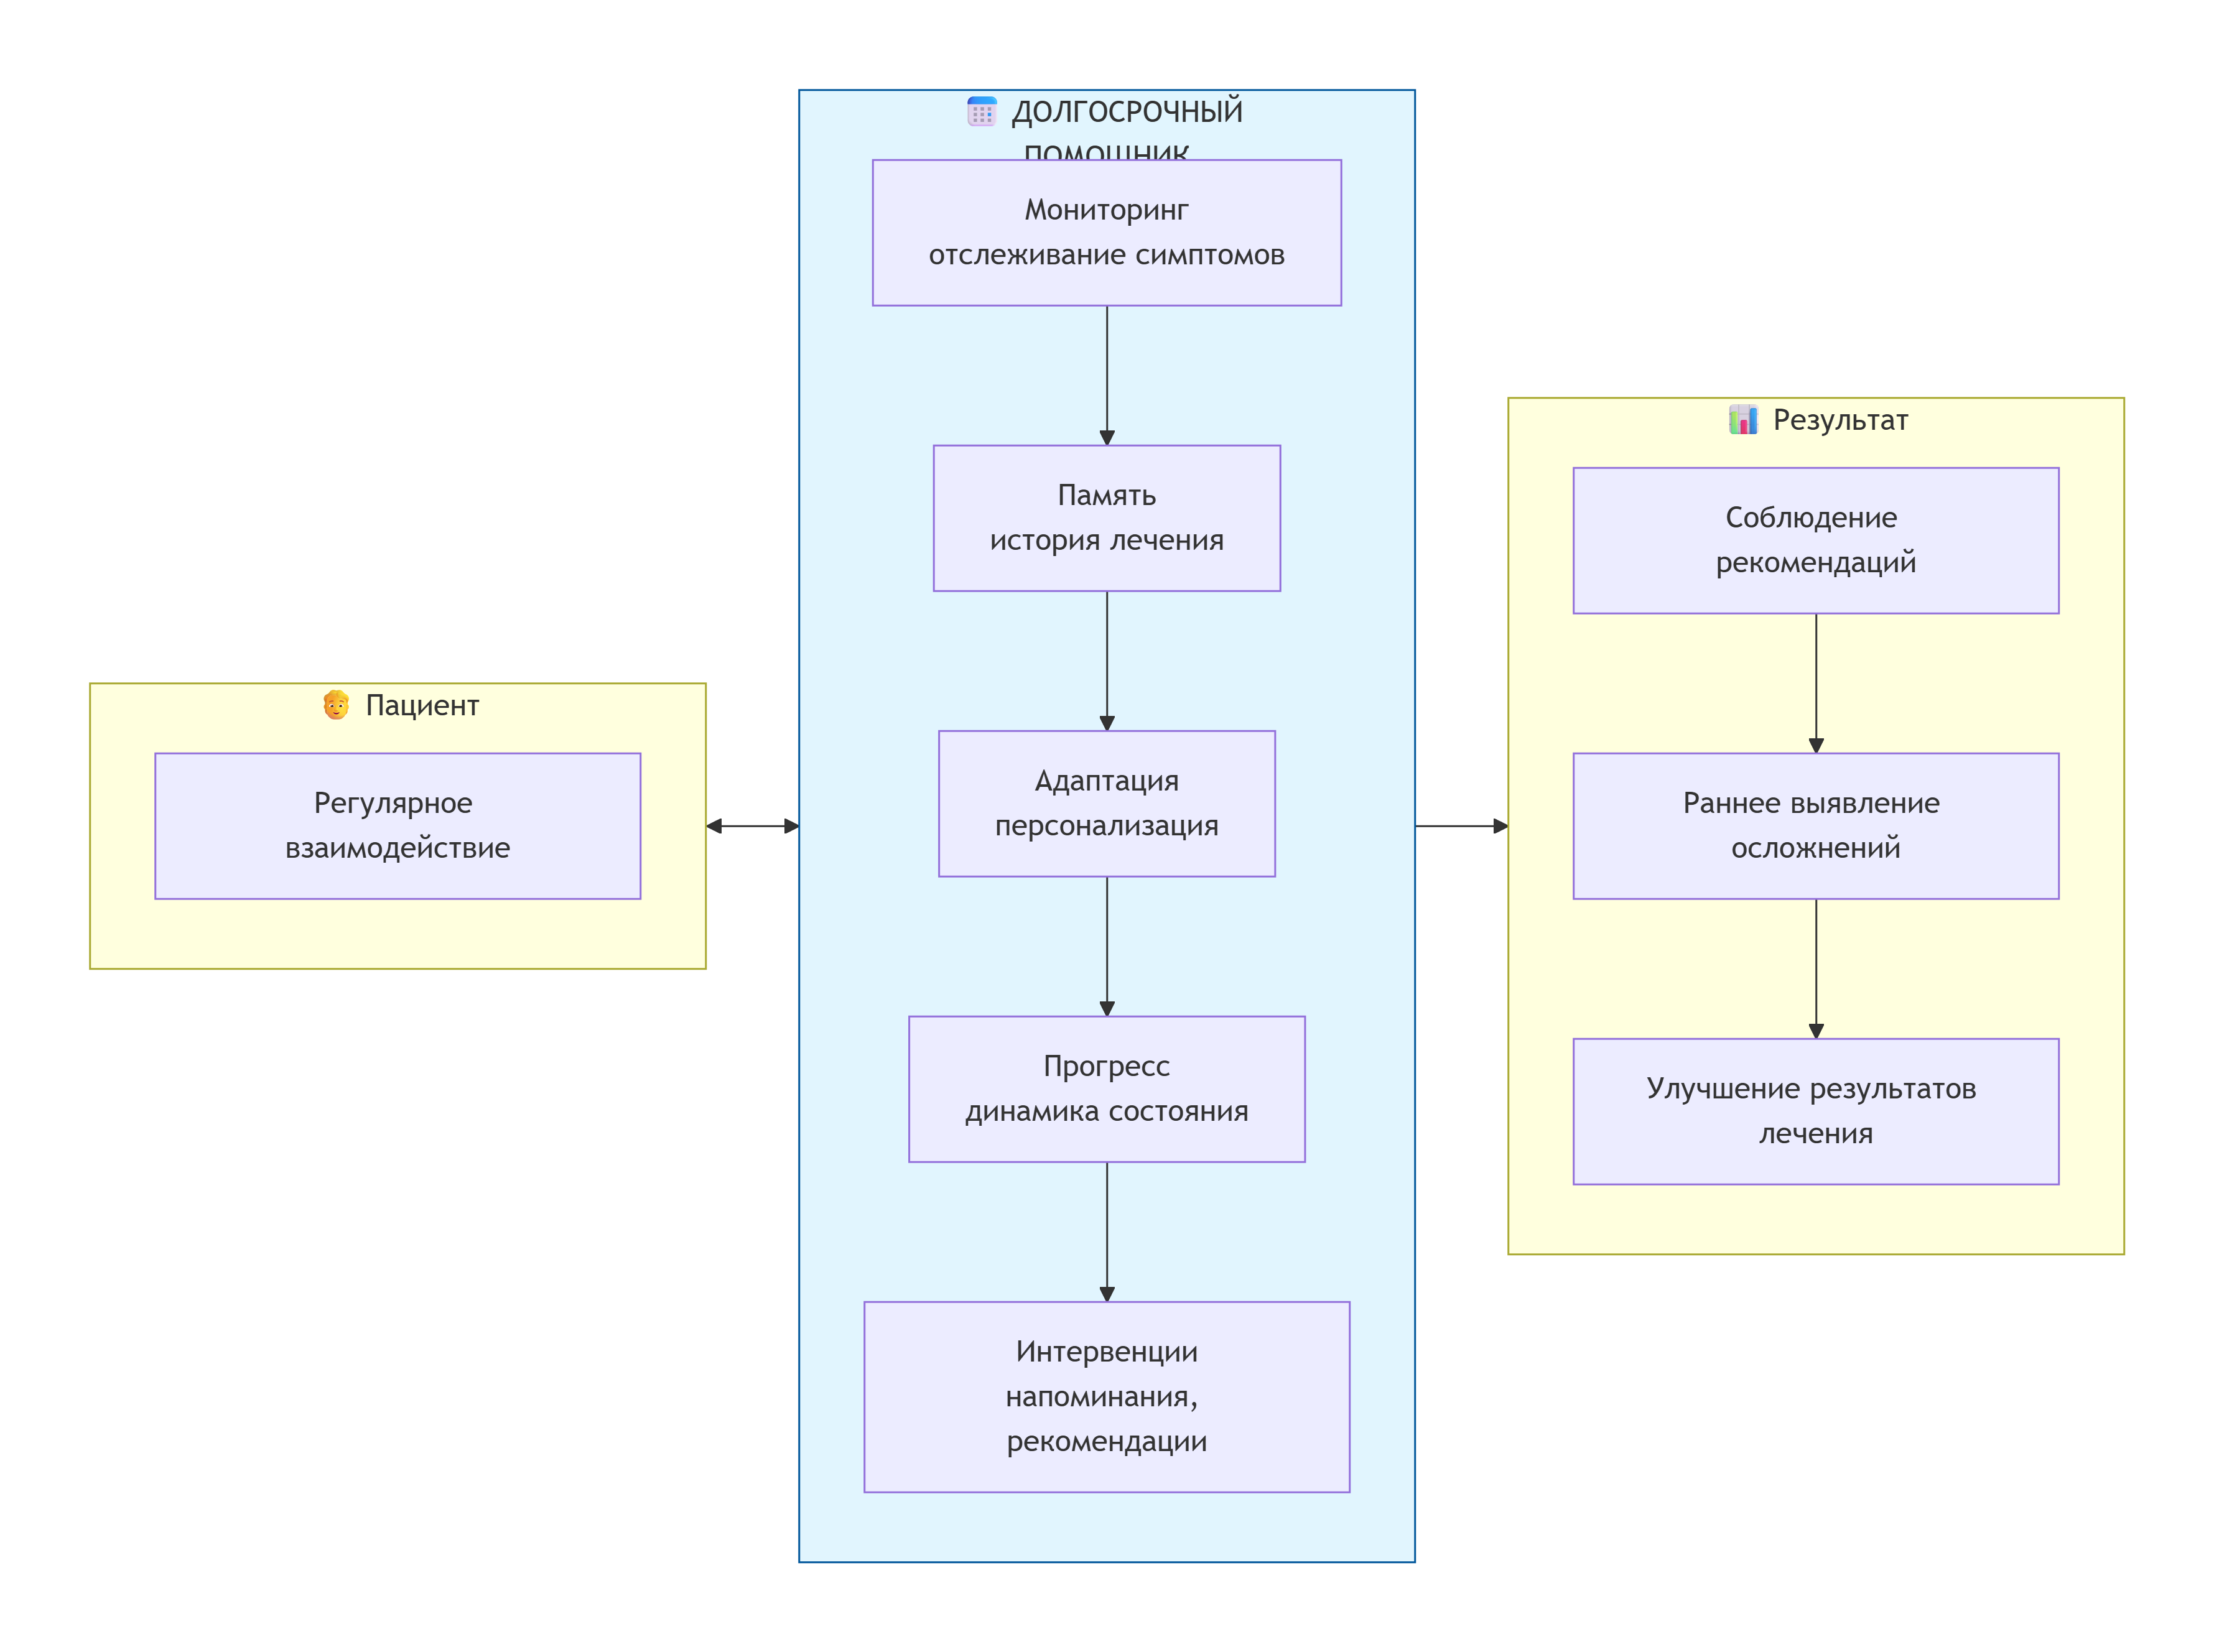



**Компоненты долгосрочного помощника:**

| Компонент | Что делает | Техническая реализация |
|-----------|------------|----------------------|
| **Долгосрочная память** | Хранит всю историю лечения | Векторная БД (Chroma) + резюме |
| **Мониторинг** | Отслеживает изменения состояния | Регулярные чек-ины, анализ жалоб |
| **Адаптация** | Меняет подход на основе данных | LLM с системным промптом + история |
| **Прогресс** | Показывает динамику | Визуализация (графики заживления, индекс гигиены) |
| **Интервенции** | Предлагает действия в нужный момент | Правила + LLM-рассуждение |

---

### 6.4. Ключевые исследования 2026 года (адаптация для стоматологии)

**Longitudinal behavioral change coaching with multi LLM agents**

Исследование 2026 года представляет LLM-базированный мультиагентный фреймворк для долгосрочного поведенческого коучинга. В стоматологии это может быть применено для:
- **Мотивации пациентов к соблюдению гигиены полости рта**.
- **Поддержки при отказе от курения** (важно для пародонтологии).
- **Долгосрочного сопровождения ортодонтических пациентов**.

**Sonia – AI Wellbeing Coach (адаптация для стоматологии)**

Sonia – это ИИ для поддержки долгосрочного личностного роста и формирования привычек. В стоматологии аналог может помогать:
- Формировать привычку регулярной чистки зубов и использования флосса.
- Сопровождать пациента после операции (напоминания о полосканиях, диете).

**UbiMyTherapist – цифровой терапевтический ассистент (адаптация для стоматологии)**

Разработка uOttawa – цифровой ассистент, который непрерывно отслеживает состояние и реагирует персонализированной поддержкой. В стоматологии это может быть:
- **Мониторинг боли после эндодонтического лечения**.
- **Контроль заживления после удаления зуба**.
- **Раннее выявление признаков периимплантита** (боль, отек, подвижность).

---

### 6.5. Тренды в развитии агентных систем для стоматологии

| Тренд | Описание | Примеры применения в стоматологии | Почему важно для врача |
|-------|----------|----------------------------------|------------------------|
| **Долгосрочная память** | Агенты запоминают историю пациента | История лечения, динамика состояния пародонта | Позволяет отслеживать эффективность лечения |
| **Мультимодальность** | Агенты работают с текстом, изображениями, голосом | Анализ снимков, фото полости рта, голосовых жалоб | Учитывает все источники информации |
| **Непрерывный мониторинг** | Отслеживание состояния в реальном времени | Мониторинг боли после операции, контроль заживления | Раннее выявление осложнений |
| **Персонализация** | Адаптация под конкретного пациента | Индивидуальные рекомендации по гигиене, диете | Повышение комплаентности |
| **Human-in-the-Loop** | Человеческий контроль критических решений | Контроль при высоком риске (флегмона, кровотечение) | Безопасность клинического применения |
| **Объяснимость** | Агенты объясняют свои решения | Почему предложен конкретный план лечения | Доверие врача к ИИ |

---

### 6.6. Сравнение эпизодического и долгосрочного помощника (стоматология)

| Критерий | Эпизодический помощник | Долгосрочный помощник |
|----------|------------------------|----------------------|
| **Память** | Только текущий диалог | Вся история лечения |
| **Персонализация** | Минимальная | Высокая (адаптация под пациента) |
| **Отслеживание прогресса** | Нет | Да (динамика индексов, заживления) |
| **Интервенции** | Общие | Персонализированные, на основе истории |
| **Пример** | Разовый опрос перед приёмом | Сопровождение пациента на протяжении лечения |
| **Техническая сложность** | Низкая | Высокая (долгосрочная память + мониторинг) |

---

### 6.7. Будущее агентных систем в стоматологии

**Краткосрочная перспектива (1–2 года):**
- Интеграция долгосрочной памяти в системы записи на приём и опроса.
- Мониторинг симптомов через мобильные приложения.
- Персонализированные напоминания о гигиене.

**Среднесрочная перспектива (3–5 лет):**
- Полноценные мультиагентные системы для дифференциальной диагностики.
- Интеграция с рентгенологическими PACS-системами.
- Автоматическое отслеживание эффективности лечения по данным осмотров.

**Долгосрочная перспектива (5+ лет):**
- ИИ-помощники как часть стандартного протокола ведения стоматологического пациента.
- Предсказание осложнений (периимплантит, кариес) и превентивные меры.
- Гибридные системы (врач + ИИ) для всех этапов лечения.

---

### 6.8. Рефлексивные вопросы для ординаторов

1. Как вы думаете, какие этические риски возникают при долгосрочном мониторинге стоматологического пациента ИИ?
2. Что произойдёт, если ИИ-помощник «запомнит» неправильную информацию о аллергии пациента?
3. Как вы будете объяснять пациенту, что его данные хранятся в долгосрочной памяти ИИ?
4. Где проходит граница между «полезным напоминанием» и «навязчивым вмешательством» в контексте стоматологического лечения?

---

**Ключевая мысль раздела:** долгосрочные персонализированные помощники – это не просто «более умные чат-боты». Это **новая парадигма** ИИ-поддержки в стоматологии, которая приближает ИИ к реальной клинической работе, обеспечивая непрерывность наблюдения и персонализацию. Но с этой силой приходит и **ответственность** за данные, приватность и качество взаимодействия.

---

## 6.9. Схема: эволюция ИИ-помощников в стоматологии


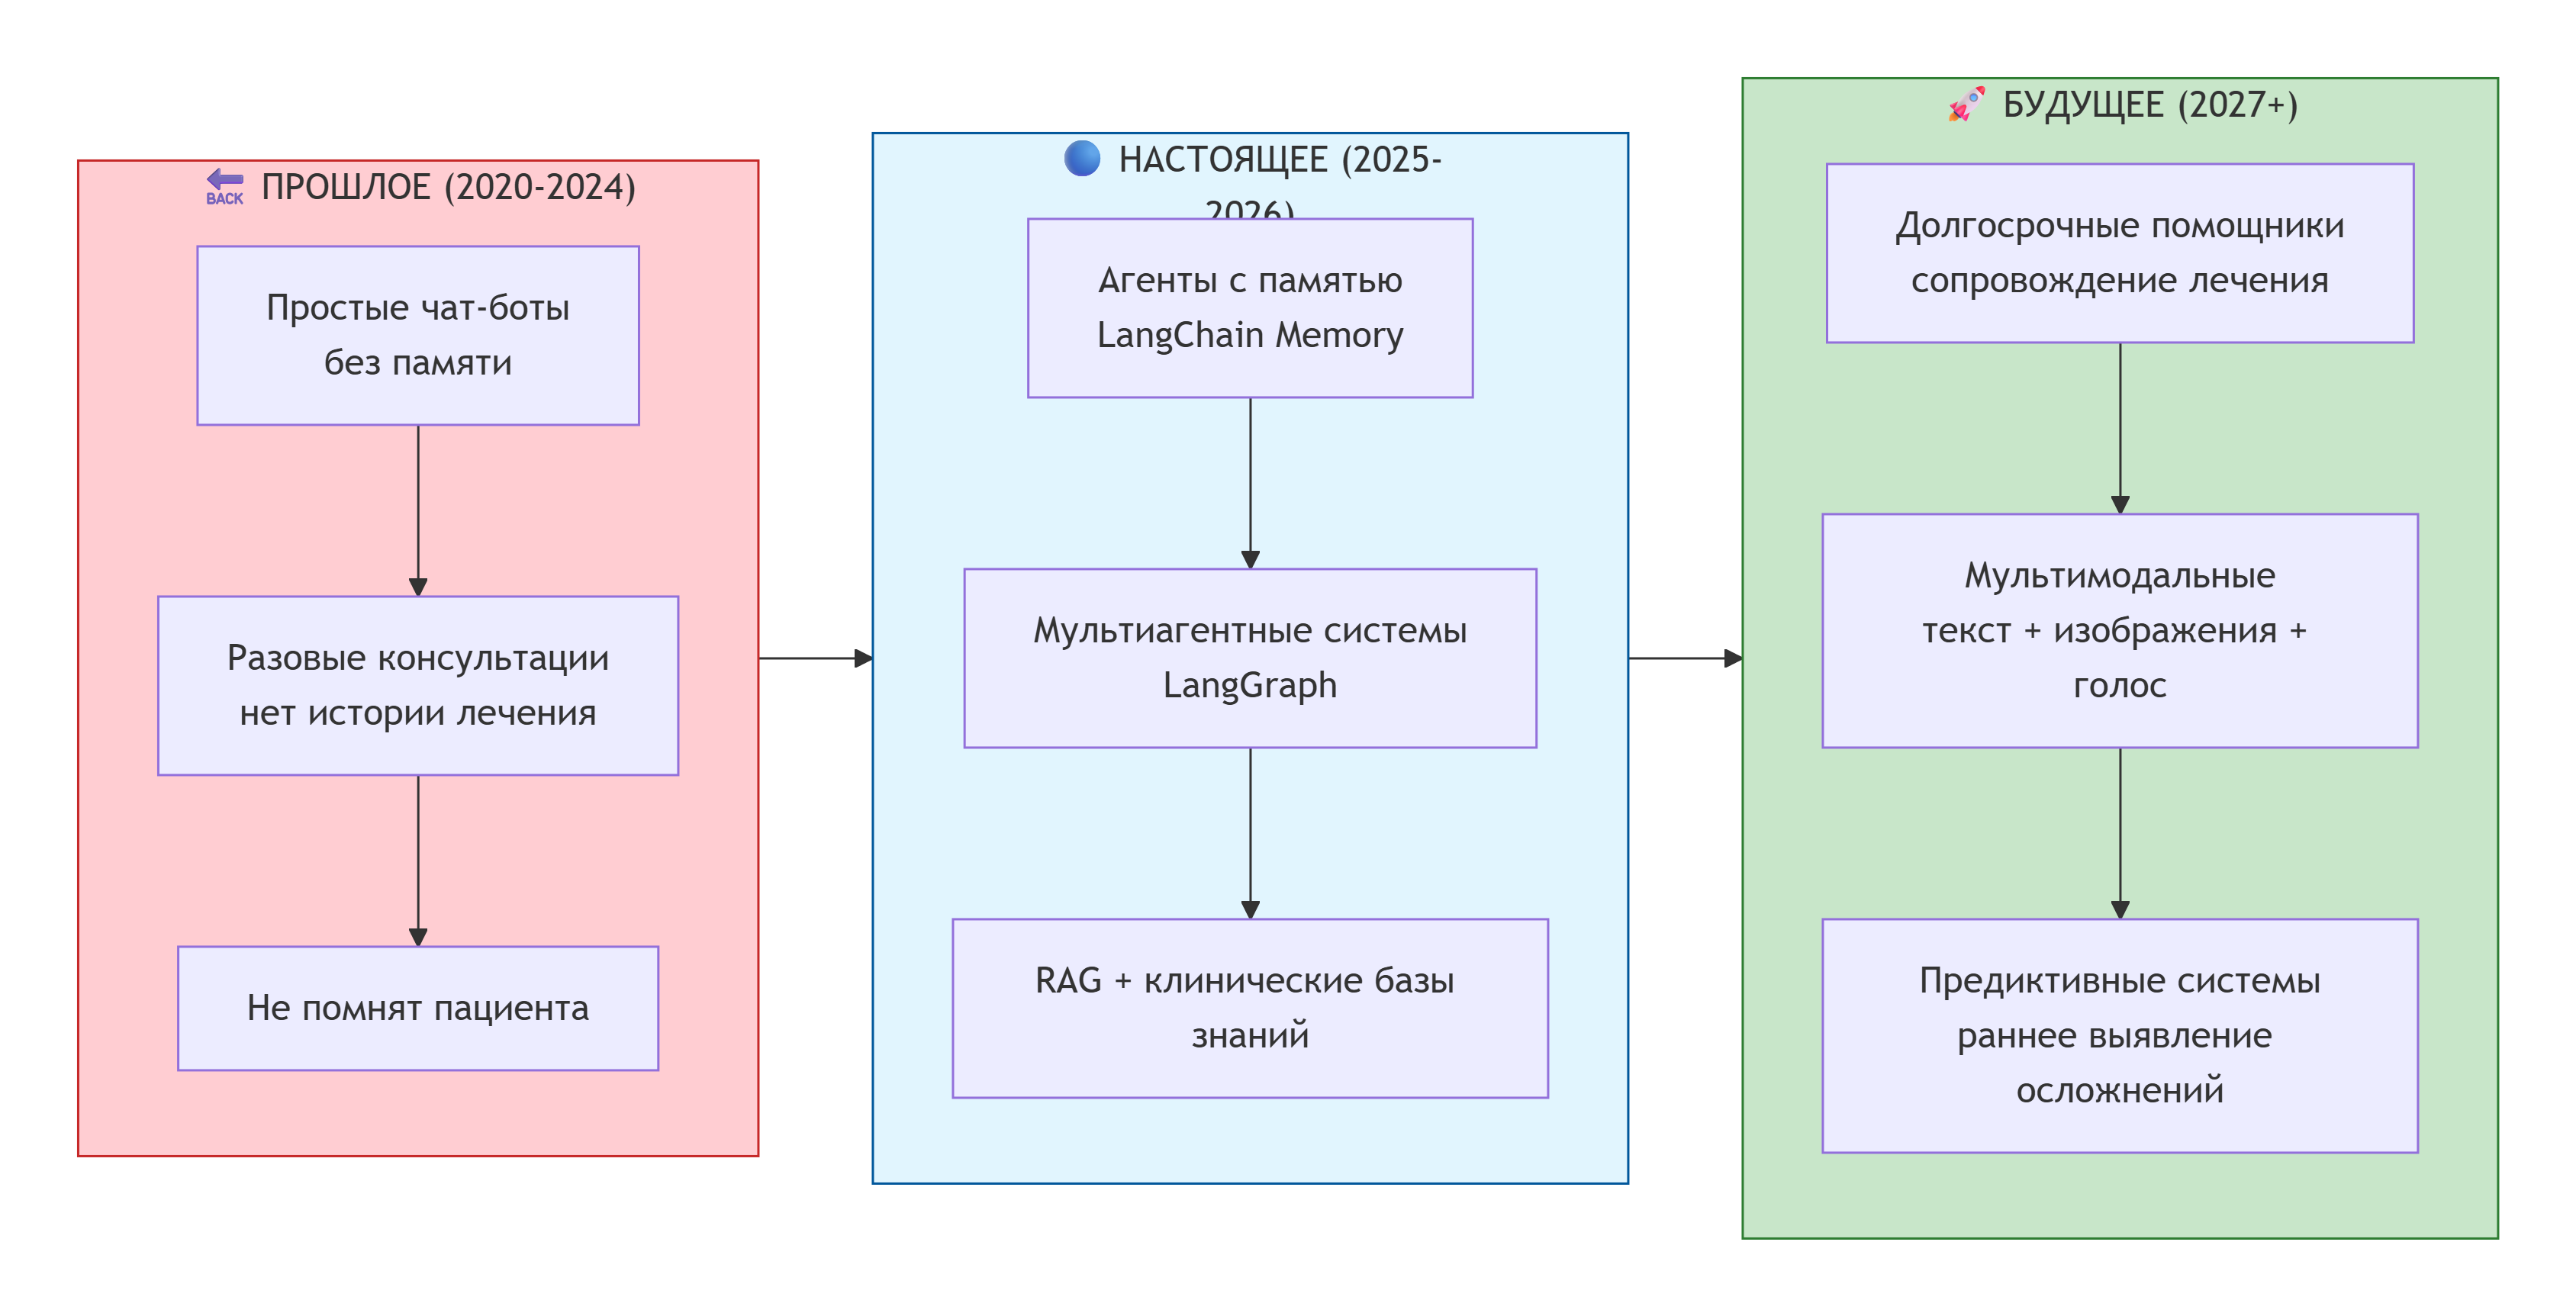



## 7. ПРАКТИЧЕСКАЯ ЧАСТЬ: КОД В GOOGLE COLAB

---

### 7.1. Введение в практическую часть

В этом разделе мы создадим **работающие прототипы** агентных систем для стоматологической практики. Все примеры кода готовы к запуску в Google Colab и используют:

- **Ollama** — для запуска локальной LLM (Qwen2.5:7B или Llama3.1:8B), обеспечивая приватность медицинских данных.
- **LangChain** — для создания агентов, инструментов и памяти.
- **LangGraph** — для построения мультиагентных систем с состоянием.
- **Chroma + SentenceTransformers** — для настоящего RAG (векторный поиск по клиническим руководствам).

**Что мы создадим:**

| Раздел | Что создаём | Что делает |
|--------|-------------|------------|
| **7.2** | Подготовка окружения | Установка всех библиотек и моделей |
| **7.3** | Single Agent (интервьюер) | Собирает стоматологический анамнез через диалог |
| **7.4** | Single Agent (аналитик) | Анализирует описания рентгенологических снимков |
| **7.5** | Multi-Agent System | Диагностика с 4 агентами (консилиум) |
| **7.6** | Multi-Agent + НАСТОЯЩИЙ RAG | Поиск информации в векторной базе знаний (Chroma) |

---

### 7.2. Подготовка окружения в Google Colab

**Перед запуском любого кода** выполните эту ячейку — она устанавливает всё необходимое.

```python
# ============================================================
# ЯЧЕЙКА 0: ПОДГОТОВКА ОКРУЖЕНИЯ (COLAB 2026 - СТОМАТОЛОГИЧЕСКИЙ ПРОФИЛЬ)
# ============================================================
# Запускается ОДИН РАЗ в начале сессии.
# ============================================================

import os
import time
import sys
import warnings
import socket
import subprocess
import urllib.request
import urllib.error

warnings.filterwarnings('ignore')

# 1. УСТАНОВКА ВСЕХ PYTHON БИБЛИОТЕК
print("⏳ Установка Python библиотек...")
!pip install langchain langchain-core langchain-community langchain-ollama langchain-classic langgraph chromadb sentence-transformers -q
print("✅ Python библиотеки установлены!")

# 2. СИСТЕМНЫЕ ЗАВИСИМОСТИ
!rm -rf /usr/local/lib/ollama /usr/local/bin/ollama
!apt-get update -qq > /dev/null 2>&1 && apt-get install -y zstd wget -qq > /dev/null 2>&1

# 3. УСТАНОВКА OLLAMA (код аналогичен предыдущим разделам)
OLLAMA_URL = "https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64.tar.zst"
ARCHIVE_PATH = "/tmp/ollama-linux-amd64.tar.zst"

print("\n⏳ Скачивание Ollama...")
for attempt in range(5):
    if os.path.exists(ARCHIVE_PATH):
        os.remove(ARCHIVE_PATH)
    !wget -q --tries=5 --timeout=20 --show-progress -O {ARCHIVE_PATH} {OLLAMA_URL}
    if os.path.exists(ARCHIVE_PATH) and os.path.getsize(ARCHIVE_PATH) > 1000000:
        print("✅ Архив скачан!")
        break
    else:
        time.sleep(5)
else:
    raise Exception("❌ Не удалось скачать Ollama.")

!tar -xf {ARCHIVE_PATH} -C /usr/local/
!chmod +x /usr/local/bin/ollama

# 4. ЗАПУСК СЕРВЕРА OLLAMA
print("\n⏳ Запуск сервера Ollama...")
with open("/tmp/ollama.log", "w") as log_file:
    subprocess.Popen(["ollama", "serve"], stdout=log_file, stderr=log_file)

time.sleep(3)
server_ready = False
for i in range(40):
    try:
        req = urllib.request.urlopen("http://localhost:11434/api/tags", timeout=2)
        if req.getcode() == 200:
            server_ready = True
            break
    except:
        time.sleep(1)

if not server_ready:
    raise Exception("❌ Сервер Ollama не запустился!")
print("✅ Сервер Ollama запущен!")

# 5. СКАЧИВАНИЕ МОДЕЛИ
MODEL_NAME = "llama3.1:8b"
print(f"\n⏳ Скачивание модели {MODEL_NAME} (~4.7 ГБ)...")
subprocess.run(["ollama", "pull", MODEL_NAME])
print(f"🎉 Модель {MODEL_NAME} загружена!")

# 6. ИМПОРТ БИБЛИОТЕК
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import initialize_agent, AgentType
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated
import operator

print("\n✅ Все импорты выполнены!")
print("\n" + "=" * 60)
print("🚀 ОКРУЖЕНИЕ ПОЛНОСТЬЮ ГОТОВО!")
print("=" * 60)
```

---

### 7.3. Single Agent: Агент-интервьюер для сбора стоматологического анамнеза

**Что делает:** агент задаёт вопросы пациенту, запоминает ответы и использует инструменты (МКБ-10, оценка риска, проверка лекарств).

```python
# ============================================================
# ЯЧЕЙКА 1: АГЕНТ-ИНТЕРВЬЮЕР (СТОМАТОЛОГИЧЕСКИЙ АНАМНЕЗ)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# 1. ЗАГРУЗКА LLM
print("⏳ Инициализация LLM...")
llm = ChatOllama(model=MODEL_NAME, temperature=0.4)
print("✅ LLM загружена!")

# 2. ОПРЕДЕЛЕНИЕ ИНСТРУМЕНТОВ
@tool
def search_icd10(query: str) -> str:
    """Поиск диагностических критериев в МКБ-10 по симптомам."""
    return f"""📖 По запросу '{query}' в МКБ-10:
    К04.5 Хронический апикальный периодонтит (боль при накусывании)
    К04.0 Пульпит (ночные боли, реакция на температурные)
    К02.1 Кариес дентина (боли от сладкого, холодного)
    K05.1 Хронический пародонтит (кровоточивость, подвижность)"""

@tool
def assess_infection_risk(text: str) -> str:
    """Оценка риска одонтогенной инфекции."""
    text_lower = text.lower()
    if any(kw in text_lower for kw in ["отек щеки", "тризм", "дисфагия", "температура", "распростран"]):
        return "🔴 ВЫСОКИЙ РИСК! Требуется срочный осмотр хирурга."
    if any(kw in text_lower for kw in ["припухлость", "локальный отек"]):
        return "🟡 УМЕРЕННЫЙ РИСК. Рекомендована консультация хирурга."
    return "🟢 РИСК НИЗКИЙ."

@tool
def check_drug_interactions(medications: str) -> str:
    """Проверка взаимодействия с антикоагулянтами/антиагрегантами."""
    if "варфарин" in medications.lower():
        return "🔴 Прием варфарина! Требуется консультация кардиолога."
    if "кардиомагнил" in medications.lower() or "аспирин" in medications.lower():
        return "⚠️ Прием антиагрегантов. Риск кровотечения."
    return "✅ Препаратов, влияющих на свертываемость, не выявлено."

tools = [search_icd10, assess_infection_risk, check_drug_interactions]

# 3. ПАМЯТЬ И АГЕНТ
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

SYSTEM_PROMPT = """Ты – ассистент врача-стоматолога. Собираешь структурированный анамнез.
Задавай один вопрос за раз. Запоминай ответы. Используй инструменты.
Отвечай ТОЛЬКО на русском языке. Все входные данные для инструментов – ТОЛЬКО строка."""

agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=5,
    handle_parsing_errors=True,
    agent_kwargs={"prefix": SYSTEM_PROMPT}
)
print("✅ Агент-интервьюер создан!")

# 4. ТЕСТИРОВАНИЕ
def interview(patient_text: str):
    print(f"\n🧑 Пациент: {patient_text}")
    response = agent.invoke({"input": patient_text})
    print(f"🦷 Интервьюер: {response['output']}")

memory.clear()
interview("Болит зуб внизу слева, больно накусывать. Десна припухла.")
interview("Принимаю кардиомагнил. Аллергия на пенициллин.")
interview("Боль усилилась ночью, температура 37.8.")
```

---

### 7.4. Single Agent: Агент-аналитик рентгенологических заключений

**Что делает:** анализирует текстовые описания рентгеновских снимков, выявляет паттерны, оценивает плотность кости.

```python
# ============================================================
# ЯЧЕЙКА 2: АГЕНТ-АНАЛИТИК РЕНТГЕНОЛОГИЧЕСКИХ ДАННЫХ
# ============================================================

@tool
def detect_radiographic_patterns(description: str) -> str:
    """Выявление рентгенологических паттернов в описании снимка."""
    patterns = {
        "периапикальное просветление": "Апикальный периодонтит / киста",
        "резорбция": "Резорбция корня / кости",
        "остеопороз": "Снижение плотности кости",
        "затемнение пазухи": "Одонтогенный гайморит"
    }
    found = [f"{k} → {v}" for k, v in patterns.items() if k in description.lower()]
    if found:
        return "🩻 Выявлены паттерны:\n" + "\n".join(found)
    return "🩻 Специфических паттернов не выявлено."

@tool
def assess_bone_density(description: str) -> str:
    """Оценка плотности костной ткани."""
    if "остеопения" in description.lower() or "остеопороз" in description.lower():
        return "⚠️ Снижение плотности кости. Рекомендована консультация эндокринолога."
    return "✅ Плотность кости в норме."

tools = [detect_radiographic_patterns, assess_bone_density]

memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)
analyst_agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    memory=memory,
    verbose=True,
    max_iterations=3,
    handle_parsing_errors=True,
    agent_kwargs={"prefix": "Ты – рентгенолог, анализирующий описания снимков. Отвечай на русском."}
)

def analyze_xray(description: str):
    print(f"\n🩻 Описание: {description}")
    response = analyst_agent.invoke({"input": description})
    print(f"🧠 Аналитик: {response['output']}")

memory.clear()
analyze_xray("На ОПТГ в области 46 зуба периапикальное просветление с нечеткими контурами. Резорбция костной ткани в фуркации.")
analyze_xray("Диффузное снижение плотности костной ткани. Признаки остеопороза.")
```

---

### 7.5. Multi-Agent System: Консилиум для комплексной диагностики

**Что делает:** система из 4 агентов (Интервьюер → Диагност → Рентгенолог → Супервизор), которые последовательно анализируют клинический случай.

```python
# ============================================================
# ЯЧЕЙКА 3: МУЛЬТИАГЕНТНАЯ СИСТЕМА (КОНСИЛИУМ)
# ============================================================

class DentalAssessmentState(TypedDict):
    patient_text: str
    findings: Annotated[List[str], operator.add]
    risk_level: str
    recommendations: str

def interviewer(state: DentalAssessmentState) -> dict:
    print("\n🦷 [Интервьюер] Анализирую жалобы...")
    prompt = f"""Извлеки ключевые симптомы из текста пациента. Верни список, каждый с "• ".
Текст: {state['patient_text']}"""
    response = llm.invoke(prompt)
    symptoms = [f"🦷 Интервьюер: {s.lstrip('• ')}" for s in response.content.strip().split('\n') if s.strip()]
    return {"findings": symptoms}

def diagnostician(state: DentalAssessmentState) -> dict:
    print("\n🔍 [Диагност] Формулирую диагноз...")
    findings_text = "\n".join(state.get('findings', []))
    prompt = f"""На основе симптомов определи диагноз и дифференциальные. Верни список с "• ".
Симптомы: {findings_text}"""
    response = llm.invoke(prompt)
    diagnoses = [f"🔍 Диагност: {s.lstrip('• ')}" for s in response.content.strip().split('\n') if s.strip()]
    return {"findings": diagnoses}

def radiologist(state: DentalAssessmentState) -> dict:
    print("\n🩻 [Рентгенолог] Оцениваю визуализацию...")
    findings_text = "\n".join(state.get('findings', []))
    prompt = f"""Определи показания к рентгенографии и ожидаемые изменения. Верни список с "• ".
Данные: {findings_text}"""
    response = llm.invoke(prompt)
    rad_findings = [f"🩻 Рентгенолог: {s.lstrip('• ')}" for s in response.content.strip().split('\n') if s.strip()]
    return {"findings": rad_findings}

def supervisor(state: DentalAssessmentState) -> dict:
    print("\n👨‍⚕️ [Супервизор] Формирую заключение...")
    findings_text = "\n".join(state.get('findings', []))
    risk_level = "🟢 НИЗКИЙ"
    if "отек щеки" in state['patient_text'].lower() or "тризм" in state['patient_text'].lower():
        risk_level = "🔴 ВЫСОКИЙ"
    prompt = f"""Сформируй заключение и план лечения. Уровень риска: {risk_level}.
История: {findings_text}"""
    final = llm.invoke(prompt).content.strip()
    return {"risk_level": risk_level, "recommendations": final}

workflow = StateGraph(DentalAssessmentState)
workflow.add_node("interviewer", interviewer)
workflow.add_node("diagnostician", diagnostician)
workflow.add_node("radiologist", radiologist)
workflow.add_node("supervisor", supervisor)
workflow.add_edge(START, "interviewer")
workflow.add_edge("interviewer", "diagnostician")
workflow.add_edge("diagnostician", "radiologist")
workflow.add_edge("radiologist", "supervisor")
workflow.add_edge("supervisor", END)
app = workflow.compile()

def run_diagnosis(patient_text: str):
    initial_state = {"patient_text": patient_text, "findings": [], "risk_level": "❓", "recommendations": ""}
    result = app.invoke(initial_state)
    print("\n" + "=" * 70)
    print("📋 ИТОГОВЫЙ ОТЧЁТ")
    for i, f in enumerate(result['findings'], 1):
        print(f"   {i}. {f}")
    print(f"\n📊 Риск: {result['risk_level']}")
    print(f"💊 Заключение: {result['recommendations']}")
    print("=" * 70)

run_diagnosis("Боль в 46 зубе при накусывании, припухлость десны. Боль 2 дня. На рентгене ранее расширение периодонтальной щели. Принимает аспирин.")
```

---

### 7.6. Multi-Agent + НАСТОЯЩИЙ RAG: Интеграция с векторной базой знаний (Chroma)

**Что делает:** агент-библиотекарь использует **настоящий RAG** с Chroma и эмбеддингами для поиска информации в базе клинических руководств и классификаций.

```python
# ============================================================
# ЯЧЕЙКА 4: МУЛЬТИАГЕНТ + RAG (CHROMA + ЭМБЕДДИНГИ)
# ============================================================

# Установка и импорт (включая mock OpenTelemetry для совместимости)
import os
import sys
import warnings
warnings.filterwarnings('ignore')
os.environ["ANONYMIZED_TELEMETRY"] = "False"
os.environ["OTEL_SDK_DISABLED"] = "true"

# Авто-mock OpenTelemetry (для Colab)
from unittest.mock import MagicMock
class OpenTelemetryMockFinder:
    def find_module(self, fullname, path=None):
        if fullname.startswith('opentelemetry'):
            return self
        return None
    def load_module(self, fullname):
        if fullname not in sys.modules:
            sys.modules[fullname] = MagicMock()
        return sys.modules[fullname]

sys.meta_path.insert(0, OpenTelemetryMockFinder())

import chromadb
from sentence_transformers import SentenceTransformer

# Загрузка эмбеддинг-модели
print("⏳ Загрузка эмбеддинг-модели...")
embedding_model = SentenceTransformer('intfloat/multilingual-e5-large', cache_folder='/tmp/sentence_transformers')
print("✅ Модель загружена!")

# База знаний (клинические руководства)
knowledge_base = [
    {"id": "doc_1", "text": "МКБ-10 К04.5 Хронический апикальный периодонтит: боль при накусывании, периапикальные изменения на рентгене.", "source": "МКБ-10"},
    {"id": "doc_2", "text": "К02.1 Кариес дентина: боли от сладкого, холодного. Лечение: препарирование, реставрация.", "source": "МКБ-10"},
    {"id": "doc_3", "text": "Показания к удалению зуба: хронический периодонтит при невозможности эндодонтического лечения, подвижность 3 степени.", "source": "Клинические рекомендации"},
    {"id": "doc_4", "text": "Антибиотикопрофилактика при одонтогенной инфекции: амоксициллин/клавуланат или клиндамицин при аллергии на пенициллин.", "source": "Протокол лечения"},
    {"id": "doc_5", "text": "КЛКТ показана при сложном эндодонтическом лечении, оценке состояния периапикальных тканей, планировании имплантации.", "source": "Руководство по рентгенологии"}
]

doc_texts = [d["text"] for d in knowledge_base]
doc_embeddings = embedding_model.encode(doc_texts, normalize_embeddings=True)

# Создание ChromaDB
client = chromadb.Client()
collection = client.get_or_create_collection(name="dental_knowledge")
collection.add(
    ids=[d["id"] for d in knowledge_base],
    documents=doc_texts,
    embeddings=[emb.tolist() for emb in doc_embeddings],
    metadatas=[{"source": d["source"]} for d in knowledge_base]
)

def search_knowledge(query: str, top_k: int = 3):
    query_embedding = embedding_model.encode([query], normalize_embeddings=True)[0]
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [(doc, meta["source"], 1-dist) for doc, meta, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0])]

# Тестирование RAG
print("\n🔍 Тестирование RAG-поиска:")
query = "диагностика и лечение хронического периодонтита"
results = search_knowledge(query)
for i, (doc, source, score) in enumerate(results, 1):
    print(f"  {i}. [Сходство: {score:.3f}] {doc[:100]}... (Источник: {source})")
```

---

### 7.7. Схема: поток данных в мультиагентной системе с RAG (стоматология)


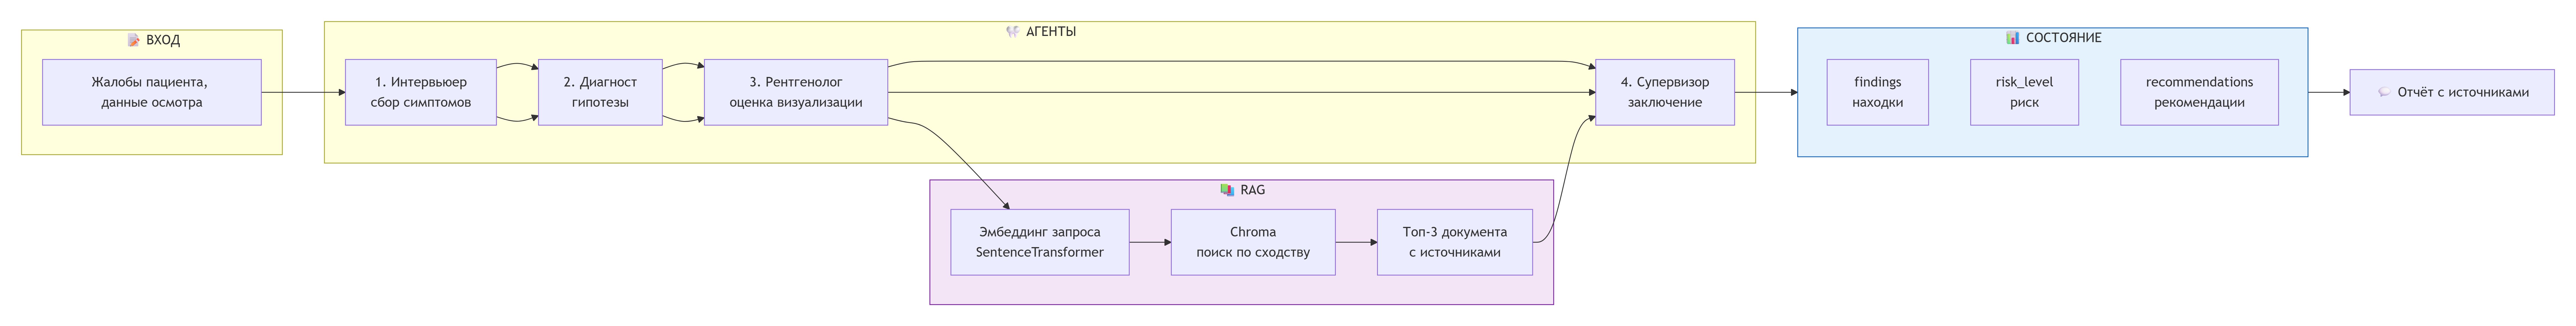



## 8. ЭТИЧЕСКИЕ АСПЕКТЫ АГЕНТНЫХ СИСТЕМ В СТОМАТОЛОГИИ

### 8.1. Ответственность за действия агентов

В агентных системах LLM **сама решает**, какие инструменты вызывать и в каком порядке. Это даёт гибкость, но создаёт риски:

| Риск | Что может пойти не так в стоматологии | Как предотвратить |
|------|------------------------|-------------------|
| **Неверный выбор инструмента** | Агент вызовет оценку риска кровотечения, когда нужна оценка инфекции | Ограничить набор инструментов, добавить валидацию |
| **Циклические действия** | Агент зациклится, бесконечно вызывая инструменты | Ограничить число итераций (`max_iterations`) |
| **Галлюцинации** | Агент «выдумает» диагноз или рекомендацию | RAG + проверка по клиническим руководствам |
| **Эскалация риска** | Агент недооценит признаки флегмоны | Human-in-the-loop для критических решений |

**Интуитивная аналогия:**

> Агентная система – это как **ординатор**, которому дали доступ к инструментам и сказали: «Делай, что считаешь нужным». Он может быть очень полезным, но за ним нужен **контроль наставника**. Супервизор (врач) должен проверять его работу, особенно в критических ситуациях (подозрение на флегмону, риск кровотечения).

### 8.2. Human-in-the-Loop (HITL)

**Human-in-the-Loop** – это подход, при котором **человек** участвует в процессе принятия решений агента.

**Уровни HITL в стоматологии:**

1. **Полный контроль** – врач принимает все решения, агент только предлагает (например, агент формирует список дифференциальных диагнозов).
2. **Контроль критических точек** – агент работает автономно, но при высоком риске (признаки флегмоны, аллергия) передаёт управление врачу.
3. **Пост-проверка** – агент работает автономно, врач проверяет результаты (например, анализирует заключение перед подписью).

### 8.3. Прозрачность и объяснимость

Пациент и врач должны знать:

- Что ответ сгенерирован ИИ-агентом.
- Какие инструменты использовал агент (МКБ-10, оценка риска).
- Какие источники были использованы (клинические руководства).

**Дисклеймер для агентной системы:**

```
⚠️ Этот ответ сгенерирован ИИ-ассистентом с использованием следующих инструментов:
- Поиск по МКБ-10
- Оценка риска одонтогенной инфекции
- Проверка лекарственных взаимодействий

Ответы НЕ являются окончательным диагнозом. Всегда проверяйте информацию и консультируйтесь
с лечащим врачом.

При признаках острого воспаления (отек, температура, тризм) немедленно обратитесь за неотложной помощью.
```

### 8.4. Схема: этический чек-лист для агентных систем в стоматологии


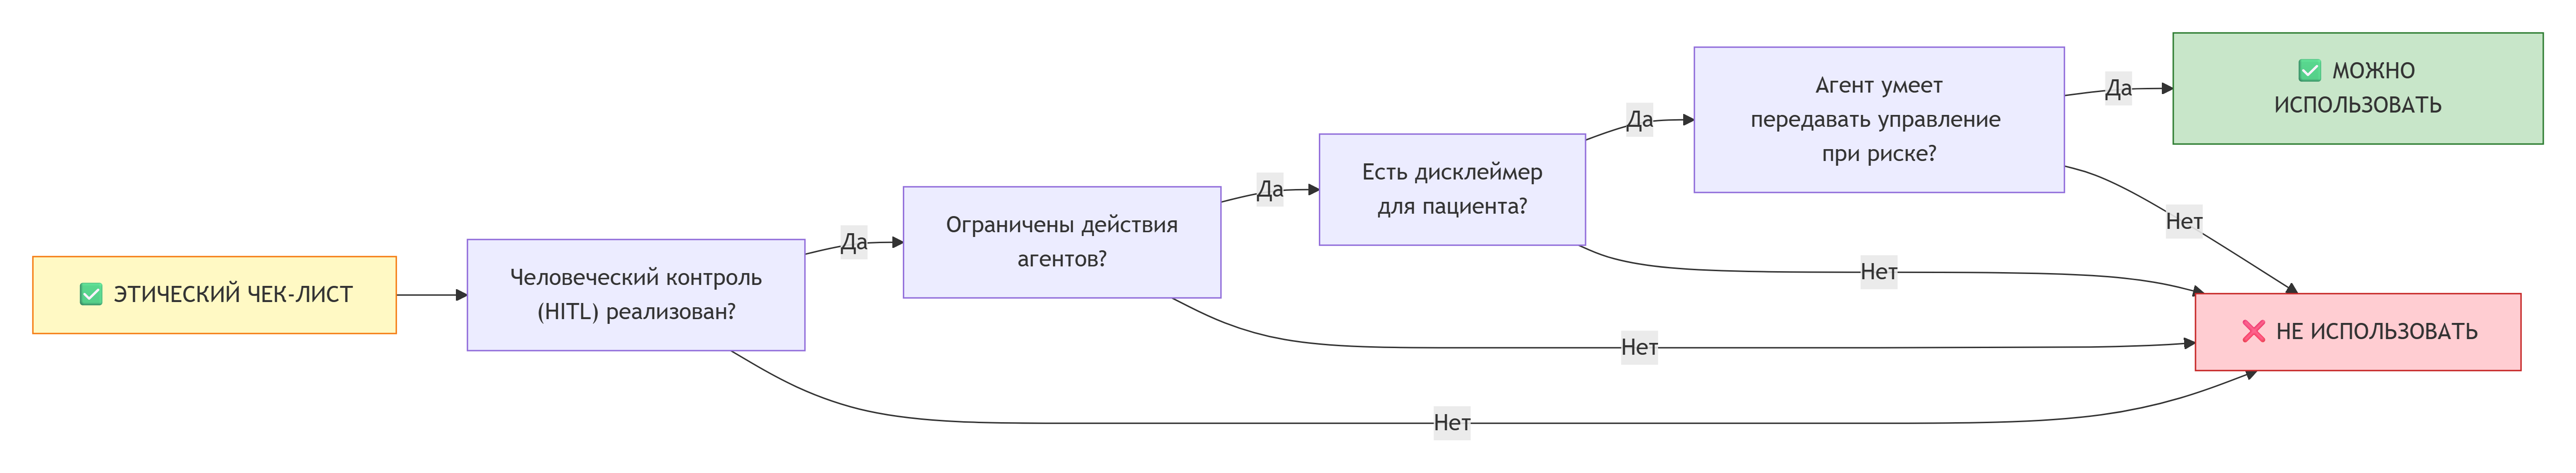



## 9. ЗАКЛЮЧЕНИЕ

**Что мы сегодня узнали:**

| Что узнали | Ключевая идея | Инструменты |
|------------|---------------|-------------|
| **Агент** | LLM + планирование + память + инструменты | Ollama + LangChain |
| **Агент-интервьюер** | Сбор стоматологического анамнеза через диалог | LangChain Chains |
| **Мультиагентная система** | Команда специализированных агентов (консилиум) | LangGraph |
| **Кооперация агентов** | Опрос + диагностика + рентген + контроль | LangGraph State |
| **Долгосрочные помощники** | Персонализация, память, непрерывность наблюдения | LangChain Memory |
| **Human-in-the-Loop** | Человеческий контроль | Интеграция с LangGraph |

**Ключевая мысль:**

> Агентные системы – это **эволюция** ИИ-инструментов для стоматологии. От простых чат-ботов мы переходим к системам, которые могут **планировать**, **искать**, **анализировать**, **запоминать** и **принимать решения** в рамках клинического алгоритма. **LangChain** даёт нам инструменты для создания агентов, а **LangGraph** – для координации их работы, имитируя междисциплинарный консилиум. **Ollama** позволяет запускать всё это локально, сохраняя приватность данных. Но с ростом возможностей растёт и **ответственность**. Человеческий контроль, прозрачность и этика – не дополнительные опции, а **обязательные компоненты** любой агентной системы в стоматологии.

---

## 10. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ

1. Что такое агент в контексте LLM? Чем он отличается от обычного чат-бота?

2. Какие четыре ключевых компонента есть у агента? Приведите аналогию из стоматологической практики.

3. Что такое память агента? Чем краткосрочная память отличается от долгосрочной? Приведите пример для стоматологического пациента.

4. Как LangChain помогает в создании агентов для стоматологии?

5. Что такое LangGraph и для чего он используется в мультиагентных системах?

6. Как работает агент-интервьюер для сбора стоматологического анамнеза? Какие инструменты он может использовать?

7. Что такое мультиагентная система? Приведите пример из стоматологической практики.

8. Как агенты кооперируются в мультиагентной системе с LangGraph? Что такое состояние (State)?

9. Какие тренды 2026 года в области долгосрочных персонализированных помощников вы знаете? Как они могут быть применены в стоматологии?

10. **Рефлексивный вопрос:** как вы видите использование агентных систем с Ollama, LangChain и LangGraph в своей будущей практике (терапия, рентгенология, микробиология, неонатология)? Где проходит граница между «помощником» и «заменой» врача?

---

## 11. ДОМАШНЕЕ ЗАДАНИЕ (срок – 2 недели)

**Часть 1. Сравнение Single Agent и Multi-Agent (2–3 страницы)**

Напишите эссе на тему:
*«Когда использовать одного агента, а когда – мультиагентную систему в стоматологической практике?»*

Включите:
- Сравнение подходов (таблица).
- 3 примера задач, где лучше один агент (например, сбор анамнеза, анализ одного снимка).
- 3 примера задач, где лучше мультиагентная система (например, комплексная диагностика, планирование имплантации).
- Обоснование вашего выбора с учетом вашей специальности.

---

**Часть 2. Создание агента-интервьюера с LangChain (код + отчёт)**

Создайте агента-интервьюера для сбора стоматологического анамнеза по инструкции из лекции.

**Требования:**
- Использовать локальную LLM через Ollama.
- Добавить минимум 2 инструмента (например, оценка риска, поиск по МКБ-10).
- Реализовать память (Memory).

**Что сдать:**
1. Полный код.
2. Примеры диалогов (3–4).
3. Рефлексия (1 стр.): что получилось, что нет.

---

**Часть 3. Проектирование мультиагентной системы с LangGraph (1–2 страницы)**

Спроектируйте мультиагентную систему с LangGraph для одной из задач (адаптируйте под свою специальность):
- Диагностика периодонтита.
- Оценка состояния периапикальных тканей по данным КЛКТ.
- Планирование эндодонтического лечения.
- Оценка риска одонтогенной инфекции.

**Что сдать:**
1. Схему графа (Mermaid или рисунок).
2. Описание каждого агента (узла) и его роли.
3. Описание переходов (рёбер) между агентами.
4. Описание состояния (State).

---

**Часть 4. Рефлексия об этике (1–2 страницы)**

Напишите эссе на тему:
*«Агентные системы с Ollama, LangChain и LangGraph в стоматологии: возможности и этические границы»*

Включите:
- Какие возможности открывают агентные системы с локальными LLM для вашей специальности?
- Какие этические риски вы видите (конфиденциальность, ошибки, гипердиагностика)?
- Как вы будете обеспечивать Human-in-the-Loop?
- Как вы будете объяснять пациенту использование агентов?

---

## 12. ЛИТЕРАТУРА

1. WiseMind: a knowledge-guided multi-agent framework for accurate and empathetic psychiatric diagnosis. (2026). *npj Digital Medicine*, 9, 575. (Адаптируется для стоматологии)

2. AgentMental: An Interactive Multi-Agent Framework for Explainable and Adaptive Mental Health Assessment. (2026). *AAAI 2026*.

3. IntegraMind: An Intelligent Framework for Unified Assessment and Intervention in Dual Diagnosis. (2026). *International Journal of Computational Intelligence Systems*, 19, 191.

4. MoodAngels: A Retrieval-augmented Multi-agent Framework for Psychiatry Diagnosis. (2026). *NeurIPS 2026*.

5. EvoMem: a multi-agent framework built on a dual-evolving memory mechanism. (2026). *arXiv*.

6. StoryMI: Steerable Multi-Agent Therapeutic Dialogue Generation. (2026). *Findings of ACL 2026*.

7. CCD-CBT: Multi-Agent Therapeutic Interaction for CBT Guided by Cognitive Conceptualization Diagram. (2026). *arXiv:2604.01567*.

8. XInsight: Integrative Stage-Consistent Psychological Counseling Support Agents for Digital Well-Being. (2026). *arXiv:2601.02345*.

9. DELTA: Deliberative Multi-Agent Reasoning with Reinforcement Learning for Multimodal Psychological Counseling. (2026). *arXiv:2602.04112*.

10. From Pattern Recognizers to Personalized Companions: a Survey of Large Language Models in Mental Health. (2026). *IEEE Xplore*.

11. Longitudinal behavioral change coaching with multi LLM agents: Multi-scale summaries and automated dialogue steering. (2026). *ScienceDirect*.

12. UbiMyTherapist: AI Companion Agent for Mental Health. (2026). *uOttawa Research*.

13. Emotimate - AI Companion Agent for Mental Health Using Multimodal Generative AI. (2026). *IEEE Xplore*.

14. LangChain Documentation (2026). *Agents*. https://python.langchain.com/docs/modules/agents

15. LangGraph Documentation (2026). *Multi-Agent Systems*. https://langchain-ai.github.io/langgraph

16. Ollama Documentation (2026). *Getting Started*. https://docs.ollama.com

17. Федеральный закон № 152-ФЗ «О персональных данных» (2006).

18. Международная классификация болезней МКБ-10 (для стоматологических нозологий).

19. Клинические рекомендации по стоматологии (Российское общество стоматологов, 2025-2026).